In [1]:
import numpy as np
from behavior_models import models
from one.api import ONE
from brainbox.io.one import SessionLoader
import pandas as pd
from joblib import Parallel, delayed
from matplotlib import pyplot as plt


### Action Kernel Prior

In [2]:
one = ONE(base_url="https://openalyx.internationalbrainlab.org", password="international")
# eids_df = pd.read_csv('D:\personal\phD\code\information-decomposition\ibl-partial-info-decomp\data\processed\eids_to_analyse.csv')
# eids = eids_df.eid

eids = np.load('../data/processed/eids_with_detailed_insertions.npy',allow_pickle=True)


# for eid in eids:
#     sl = SessionLoader(one=one, eid=eid)
#     sl.load_trials()

#     my_model = models.ActionKernel(path_to_results="../models/results_behavioral/", session_uuids=eid, df_trials=sl.trials, single_zeta=False)
#     my_model.load_or_train(remove_old=False, adaptive=True)




In [9]:
def runactionkernelprior(eid, one):
    sl = SessionLoader(one=one, eid=eid)
    sl.load_trials()
    my_model = models.ActionKernel(path_to_results="../models/results_behavioral/", session_uuids=eid, df_trials=sl.trials, single_zeta=False)
    my_model.load_or_train(remove_old=False, adaptive=True)
    df_prior = my_model.predict_trials()
    df_prior.to_csv(f'../data/raw/{eid}_actionkernel_prior.csv', index=False)


In [3]:
df_prior = pd.read_csv('../data/raw/032ffcdf-7692-40b3-b9ff-8def1fc18b2e_actionkernel_prior.csv')

In [7]:
df_prior['prior-binary'] = np.asarray(df_prior['prior']>=0.5, dtype=np.int16)

In [8]:
df_prior

,prior,prediction_error_left,prediction_error_right,prior-binary
0,0.500000,0.164568,0.835432,1
1,0.655835,0.869758,0.130242,1
2,0.451431,0.167162,0.832838,0
3,0.622403,0.946138,0.053862,1
4,0.428419,0.548810,0.451190,0
...,...,...,...,...
576,0.813126,0.171800,0.828200,1
577,0.559700,0.446188,0.553812,1
578,0.385258,0.255985,0.744015,0
579,0.265185,0.888883,0.111117,0


In [13]:
my_model = models.ActionKernel(path_to_results="../models/results_behavioral/", session_uuids=eids[0], df_trials=sl.trials, single_zeta=False)

In [14]:
my_model.load_or_train(remove_old=False, adaptive=True)

2024-09-18 13:52:03 INFO     base_models.py:109  Launching MCMC procedure with 4 chains, 5000 max steps and [0.05 0.04 0.04 0.02 0.02] std_RW. Early stopping is activated
2024-09-18 13:52:03 INFO     base_models.py:119  with adaptive MCMC...
2024-09-18 13:52:03 INFO     base_models.py:121  initial point for MCMC is [[0.5    0.5    0.5    0.25   0.25  ]
 [0.75   0.25   0.75   0.125  0.375 ]
 [0.25   0.75   0.25   0.375  0.125 ]
 [0.375  0.375  0.625  0.0625 0.4375]]


 10%|█         | 500/5000 [01:39<15:43,  4.77it/s]

2024-09-18 13:53:43 INFO     base_models.py:165  Adaptive MCMC starting...


 12%|█▏        | 600/5000 [01:59<14:54,  4.92it/s]

2024-09-18 13:54:03 INFO     base_models.py:189  acceptance is 0.18333333333333335


...

 20%|██        | 1000/5000 [03:26<15:03,  4.43it/s]

2024-09-18 13:55:30 INFO     base_models.py:189  acceptance is 0.1955


 20%|██        | 1001/5000 [03:26<14:48,  4.50it/s]

2024-09-18 13:55:30 INFO     base_models.py:159  Early stopping criteria was validated at step 1001. R values are: [1.00109675 1.02546045 1.08827535 1.01943613 1.07052774]


2024-09-18 13:55:30 INFO     base_models.py:194  final posterior_mean is [0.12455651 0.07547925 0.05432001 0.09212725 0.01895787]
2024-09-18 13:55:30 INFO     base_models.py:203  acceptance ratio is of 0.1953046953046953. Careful, this ratio should be close to 0.234. If not, change the standard deviation of the random walk
2024-09-18 13:55:30 INFO     base_models.py:312  results of inference SAVED in results_behavioral\model_actKernel\train_b52182e7.pkl


In [15]:

# predict trials and eventually join in the original dataframe
df_prior = my_model.predict_trials()
df_trials = sl.trials.join(df_prior, how='left')

In [23]:
action_kernel_prior = df_trials['prior']


In [19]:
true_block_prior = df_trials['probabilityLeft']

In [20]:
from matplotlib import pyplot as plt

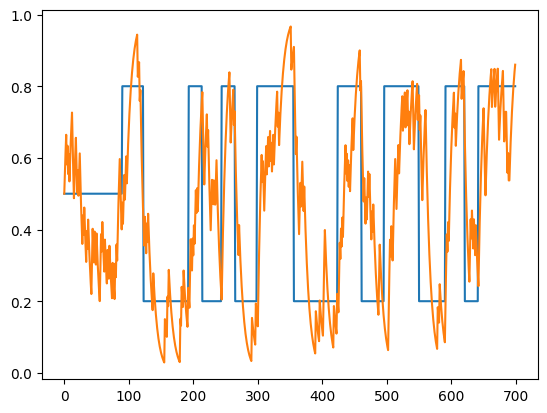

In [24]:
plt.plot(true_block_prior)
plt.plot(action_kernel_prior)

In [11]:
df_prior = pd.read_csv('../data/raw/032ffcdf-7692-40b3-b9ff-8def1fc18b2e_actionkernel_prior.csv')

In [12]:
df_prior

,prior,prediction_error_left,prediction_error_right
0,0.500000,0.164568,0.835432
1,0.655835,0.869758,0.130242
2,0.451431,0.167162,0.832838
3,0.622403,0.946138,0.053862
4,0.428419,0.548810,0.451190
...,...,...,...
576,0.813126,0.171800,0.828200
577,0.559700,0.446188,0.553812
578,0.385258,0.255985,0.744015
579,0.265185,0.888883,0.111117


In [14]:
from brainwidemap.bwm_loading import load_trials_and_mask

In [17]:
df,mask = load_trials_and_mask(one, eids[0])

### RNNs

In [2]:
import pickle as pkl

### Setup pid for rnn model 


In [132]:
# try old data
from ibl_info.broja_pid import compute_pid, coinformation, compute_pid_unbiased, unbiasedMI, MI

2024-11-21 13:17:05.878 | INFO     | ibl_info.config:<module>:11 - PROJ_ROOT path is: D:\personal\phD\code\information-decomposition\ibl-partial-info-decomp


In [3]:
from idtxl.bivariate_mi import BivariateMI
from idtxl.bivariate_te import BivariateTE

In [5]:
# session_id = eids[0]
# sl = SessionLoader(one=one, eid=session_id)
# sl.load_trials()
# sl.trials

In [4]:
with open('../models/rnn_ann_model_results.pkl','rb') as f:
    trained_model = pkl.load(f)

In [5]:
session_data = trained_model['session_data']

In [ ]:
action_data = session_data.loc[
        session_data['action_taken'] == 1,
        ['block_side', 'signed_trial_strength', 'action_side','trial_side','correct_action_taken','hidden_state','left_stimulus','right_stimulus']]
action_data['signed_trial_strength'] /= action_data['signed_trial_strength'].max()
action_data['opt_bayesian'] = signal

<Axes: >

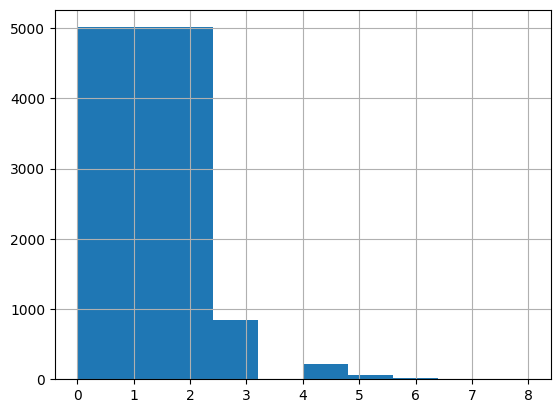

In [7]:
session_data['rnn_step_index'].hist()

,rnn_step_within_session,trial_within_session,block_index,trial_index,rnn_step_index,block_side,trial_side,trial_strength,trial_start,trial_end,...,action_side,correct_action_taken,session_index,1_back_correct,2_back_correct,3_back_correct,signed_trial_strength,concordant_trial,correct_trial_dt,trial_side_orthogonal
0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.5,1.0,NaN,...,NaN,NaN,0,NaN,NaN,NaN,0.5,True,1.0,0.418457
1,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.5,NaN,NaN,...,NaN,NaN,0,NaN,NaN,NaN,0.5,True,1.0,0.418457
2,2.0,0.0,0.0,0.0,2.0,1.0,1.0,0.5,NaN,NaN,...,NaN,NaN,0,NaN,NaN,NaN,0.5,True,1.0,0.418457
3,3.0,0.0,0.0,0.0,3.0,1.0,1.0,0.5,NaN,1.0,...,1.0,1.0,0,NaN,NaN,NaN,0.5,True,1.0,0.418457
4,4.0,1.0,0.0,1.0,0.0,1.0,1.0,1.5,1.0,NaN,...,NaN,NaN,0,NaN,NaN,NaN,1.5,True,1.0,0.418457


In [ ]:
# plot left and right stimulus values at t0, t1 and t2



In [95]:
# ask peter, for now just do everything on the action trial

In [96]:
action_data

,block_side,signed_trial_strength,action_side,trial_side,correct_action_taken,hidden_state,left_stimulus,right_stimulus
3,1.0,0.199951,1.0,1.0,1.0,"[[-0.33558813067514154, -0.45776661454258005, ...",-0.640137,0.412354
6,1.0,0.600098,1.0,1.0,1.0,"[[-0.2991012494556518, -0.2643218143021266, 0....",0.675781,1.111328
9,1.0,0.399902,1.0,1.0,1.0,"[[-0.7252658334326196, -0.5024673096366877, 0....",-1.231445,2.142578
12,1.0,0.600098,1.0,1.0,1.0,"[[-0.8431474180724741, -0.27047470563437104, 0...",-1.903320,2.478516
15,1.0,0.600098,1.0,1.0,1.0,"[[-0.8319826679786207, -0.07369130127681635, 0...",-1.213867,2.484375
...,...,...,...,...,...,...,...,...
16181,-1.0,-0.600098,1.0,-1.0,0.0,"[[-0.6170365753399453, -0.23021537547549117, 0...",-1.142578,0.987793
16184,-1.0,-0.000000,1.0,-1.0,0.0,"[[-0.38493803309318836, 0.14676609922924708, -...",-0.231201,-0.144897
16187,-1.0,-0.600098,1.0,-1.0,0.0,"[[-0.5483682165234434, -0.08617737393520994, -...",-0.606934,0.409424
16190,-1.0,1.000000,1.0,1.0,1.0,"[[-0.6309903018180847, -0.07859663899124439, -...",-0.791992,0.838379


In [ ]:
# run opt bayesian 

In [30]:
from prior_localization.functions.behavior_targets import optimal_Bayesian
from tqdm import tqdm

In [98]:
signal = optimal_Bayesian(act=action_data['action_side'].values, side=action_data['trial_side'].values)

In [99]:
# result is the array
# this is what we discretize
action_data['opt_bayesian'] = signal

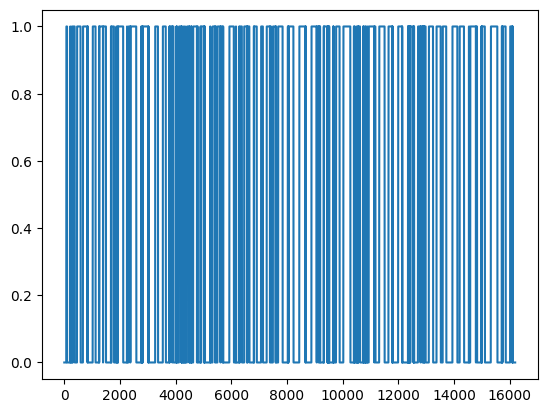

In [105]:
plt.plot(action_data.opt_bayesian>0.5)


In [8]:
def discretize_hidden_state(hidden_state, n_bins=4):
    """
    Discretize the hidden state into equipopulated bins

    Args:
        hidden_state (np.array): activations for neurons x trials
        method (str, optional): how to determine the percenille. 
                                Defaults to 'neuron'. Calculate the percentile per neuron
                                Other options: 'all': Calculate the percentile based on the entire dataset
    """
    
    
    discrete_data = np.zeros((hidden_state.shape[0], hidden_state.shape[1]))
    # discretize per recorded neuron
    for idx in tqdm(range(hidden_state.shape[0])):

        row = hidden_state[idx, :]
        #bin_edges = np.percentile(row, [20,40,60,80])
        # set bin edges to 4 parts
        #bin_edges = np.percentile(row, [25,50,75])
        #discrete_data[idx, :] = np.digitize(row, bin_edges)
        discrete_row, bin_edges_p = pd.qcut(row, q=n_bins, labels=False, duplicates='drop', retbins=True)
        discrete_data[idx, :] = discrete_row
    
    discrete_data = np.nan_to_num(discrete_data, nan=0)
    return discrete_data

In [110]:
hidden_state = np.concatenate(action_data['hidden_state'].values)

In [111]:
hidden_state.shape

(5014, 50)

In [112]:
discretized = discretize_hidden_state(hidden_state.T)

100%|██████████| 50/50 [00:00<00:00, 594.72it/s]


In [122]:
# compute MI
action_data

,block_side,signed_trial_strength,action_side,trial_side,correct_action_taken,hidden_state,left_stimulus,right_stimulus,opt_bayesian
3,1.0,0.199951,1.0,1.0,1.0,"[[-0.33558813067514154, -0.45776661454258005, ...",-0.640137,0.412354,0.500000
6,1.0,0.600098,1.0,1.0,1.0,"[[-0.2991012494556518, -0.2643218143021266, 0....",0.675781,1.111328,0.500000
9,1.0,0.399902,1.0,1.0,1.0,"[[-0.7252658334326196, -0.5024673096366877, 0....",-1.231445,2.142578,0.500000
12,1.0,0.600098,1.0,1.0,1.0,"[[-0.8431474180724741, -0.27047470563437104, 0...",-1.903320,2.478516,0.500000
15,1.0,0.600098,1.0,1.0,1.0,"[[-0.8319826679786207, -0.07369130127681635, 0...",-1.213867,2.484375,0.500000
...,...,...,...,...,...,...,...,...,...
16181,-1.0,-0.600098,1.0,-1.0,0.0,"[[-0.6170365753399453, -0.23021537547549117, 0...",-1.142578,0.987793,0.294444
16184,-1.0,-0.000000,1.0,-1.0,0.0,"[[-0.38493803309318836, 0.14676609922924708, -...",-0.231201,-0.144897,0.240419
16187,-1.0,-0.600098,1.0,-1.0,0.0,"[[-0.5483682165234434, -0.08617737393520994, -...",-0.606934,0.409424,0.224791
16190,-1.0,1.000000,1.0,1.0,1.0,"[[-0.6309903018180847, -0.07859663899124439, -...",-0.791992,0.838379,0.220758


In [125]:
mi_trial_side = []
for idx in range(50):
    mi_trial_side.append(MI(action_data['trial_side'].values, discretized[idx,:]))

mi_trial_side = np.asarray(mi_trial_side)


mi_block_side = []
for idx in range(50):
    mi_block_side.append(MI(action_data['block_side'].values, discretized[idx,:]))

mi_block_side = np.asarray(mi_block_side)



mi_action_side = []
for idx in range(50):
    mi_action_side.append(MI(action_data['action_side'].values, discretized[idx,:]))

mi_action_side = np.asarray(mi_action_side)


In [127]:
session_data

,rnn_step_within_session,trial_within_session,block_index,trial_index,rnn_step_index,block_side,trial_side,trial_strength,trial_start,trial_end,...,action_side,correct_action_taken,session_index,1_back_correct,2_back_correct,3_back_correct,signed_trial_strength,concordant_trial,correct_trial_dt,trial_side_orthogonal
0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.5,1.0,NaN,...,NaN,NaN,0,NaN,NaN,NaN,0.5,True,1.0,0.418457
1,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.5,NaN,NaN,...,NaN,NaN,0,NaN,NaN,NaN,0.5,True,1.0,0.418457
2,2.0,0.0,0.0,0.0,2.0,1.0,1.0,0.5,NaN,NaN,...,NaN,NaN,0,NaN,NaN,NaN,0.5,True,1.0,0.418457
3,3.0,0.0,0.0,0.0,3.0,1.0,1.0,0.5,NaN,1.0,...,1.0,1.0,0,NaN,NaN,NaN,0.5,True,1.0,0.418457
4,4.0,1.0,0.0,1.0,0.0,1.0,1.0,1.5,1.0,NaN,...,NaN,NaN,0,NaN,NaN,NaN,1.5,True,1.0,0.418457
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16190,16192.0,5012.0,99.0,31.0,2.0,-1.0,1.0,2.5,NaN,1.0,...,1.0,1.0,0,0.0,0.0,0.0,2.5,False,1.0,1.582031
16191,16192.0,5012.0,99.0,32.0,0.0,-1.0,-1.0,1.5,1.0,NaN,...,NaN,NaN,0,NaN,NaN,NaN,-1.5,True,1.0,-0.418457
16192,16192.0,5012.0,99.0,32.0,1.0,-1.0,-1.0,1.5,NaN,NaN,...,NaN,NaN,0,NaN,NaN,NaN,-1.5,True,1.0,-0.418457
16193,16192.0,5012.0,99.0,32.0,2.0,-1.0,-1.0,1.5,NaN,NaN,...,NaN,NaN,0,NaN,NaN,NaN,-1.5,True,1.0,-0.418457


In [128]:
stimulus_data = session_data.loc[
        session_data['trial_start'] == 1,
        ['block_side', 'signed_trial_strength', 'action_side','trial_side','correct_action_taken','hidden_state','left_stimulus','right_stimulus']]
stimulus_data['signed_trial_strength'] /= stimulus_data['signed_trial_strength'].max()

In [129]:
stimulus_data

,block_side,signed_trial_strength,action_side,trial_side,correct_action_taken,hidden_state,left_stimulus,right_stimulus
0,1.0,0.199951,NaN,1.0,NaN,"[[-0.02440637042950045, -0.28134521052684247, ...",0.0,0.0
4,1.0,0.600098,NaN,1.0,NaN,"[[-0.2817115877083469, -0.0643035929073017, 0....",0.0,0.0
7,1.0,0.399902,NaN,1.0,NaN,"[[-0.3445547551164051, 0.052110962470801436, 0...",0.0,0.0
10,1.0,0.600098,NaN,1.0,NaN,"[[-0.5206023597121668, 0.3748425124418903, 0.0...",0.0,0.0
13,1.0,0.600098,NaN,1.0,NaN,"[[-0.5827228227676994, 0.5514557620083538, 0.0...",0.0,0.0
...,...,...,...,...,...,...,...,...
16179,-1.0,-0.600098,NaN,-1.0,NaN,"[[-0.4353699824258389, -0.13723642059146518, -...",0.0,0.0
16182,-1.0,-0.000000,NaN,-1.0,NaN,"[[-0.43065186695577745, 0.06122846982361058, -...",0.0,0.0
16185,-1.0,-0.600098,NaN,-1.0,NaN,"[[-0.3524866740395994, -0.06435483155773858, -...",0.0,0.0
16188,-1.0,1.000000,NaN,1.0,NaN,"[[-0.45483799716382556, -0.012657330396177625,...",0.0,0.0


In [130]:
hidden_state_stim = np.concatenate(stimulus_data['hidden_state'].values)

In [132]:
mi_trial_side = []
for idx in range(50):
    mi_trial_side.append(MI(stimulus_data['trial_side'].values, discretized[idx,:]))

mi_trial_side = np.asarray(mi_trial_side)


mi_block_side = []
for idx in range(50):
    mi_block_side.append(MI(stimulus_data['block_side'].values, discretized[idx,:]))

mi_block_side = np.asarray(mi_block_side)

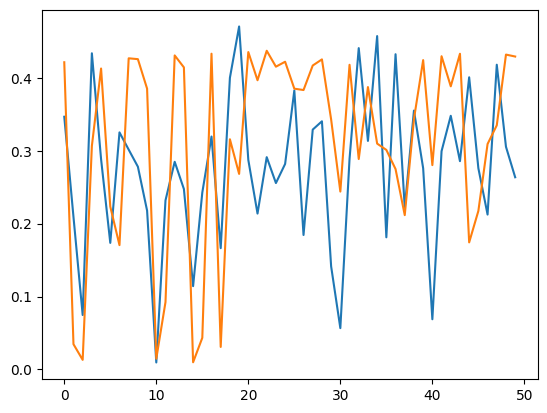

In [133]:
plt.plot(mi_block_side)
plt.plot(mi_trial_side)

,rnn_step_within_session,trial_within_session,block_index,trial_index,rnn_step_index,block_side,trial_side,trial_strength,trial_start,trial_end,...,action_side,correct_action_taken,session_index,1_back_correct,2_back_correct,3_back_correct,signed_trial_strength,concordant_trial,correct_trial_dt,trial_side_orthogonal
16194,16192.0,5012.0,99.0,32.0,3.0,-1.0,-1.0,1.5,NaN,1.0,...,-1.0,1.0,0,1.0,0.0,0.0,-1.5,True,1.0,-0.418457
16194,16192.0,5012.0,99.0,32.0,3.0,-1.0,-1.0,1.5,NaN,1.0,...,-1.0,1.0,0,1.0,0.0,0.0,-1.5,True,1.0,-0.418457
16194,16192.0,5012.0,99.0,32.0,3.0,-1.0,-1.0,1.5,NaN,1.0,...,-1.0,1.0,0,1.0,0.0,0.0,-1.5,True,1.0,-0.418457
0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.5,1.0,NaN,...,NaN,NaN,0,NaN,NaN,NaN,0.5,True,1.0,0.418457
16194,16192.0,5012.0,99.0,32.0,3.0,-1.0,-1.0,1.5,NaN,1.0,...,-1.0,1.0,0,1.0,0.0,0.0,-1.5,True,1.0,-0.418457
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.5,1.0,NaN,...,NaN,NaN,0,NaN,NaN,NaN,0.5,True,1.0,0.418457
16194,16192.0,5012.0,99.0,32.0,3.0,-1.0,-1.0,1.5,NaN,1.0,...,-1.0,1.0,0,1.0,0.0,0.0,-1.5,True,1.0,-0.418457
16194,16192.0,5012.0,99.0,32.0,3.0,-1.0,-1.0,1.5,NaN,1.0,...,-1.0,1.0,0,1.0,0.0,0.0,-1.5,True,1.0,-0.418457
16194,16192.0,5012.0,99.0,32.0,3.0,-1.0,-1.0,1.5,NaN,1.0,...,-1.0,1.0,0,1.0,0.0,0.0,-1.5,True,1.0,-0.418457


In [158]:
hidden_state_t_1 = np.concatenate(t_1['hidden_state'].values)
discretized = discretize_hidden_state(hidden_state_t_1.T)

100%|██████████| 50/50 [00:00<00:00, 677.27it/s]


In [159]:
mi_trial_side = []
for idx in range(50):
    mi_trial_side.append(MI(t_1['trial_side'].values, discretized[idx,:]))

mi_trial_side = np.asarray(mi_trial_side)


mi_block_side = []
for idx in range(50):
    mi_block_side.append(MI(t_1['block_side'].values, discretized[idx,:]))

mi_block_side = np.asarray(mi_block_side)

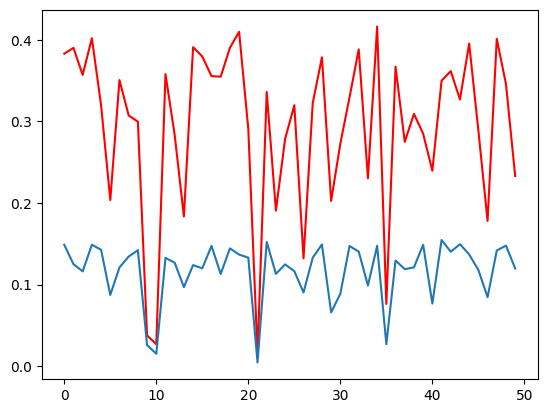

In [161]:
plt.plot(mi_block_side,'r')
plt.plot(mi_trial_side)

In [207]:
import seaborn as sns

In [313]:
# organize everything; discretize separately, and then make plots
# all decisions

def plot_all(session_data,indices,subset_bayes=False):

    iloc = np.where((session_data['action_taken'] == 1)==True)[0]
    t_1 = session_data.iloc[iloc-1][['block_side', 'signed_trial_strength', 'action_side','trial_side','correct_action_taken','hidden_state','left_stimulus','right_stimulus']]

    t_0 = session_data.loc[session_data['trial_start'] == 1,['block_side', 'signed_trial_strength', 'action_side','trial_side','correct_action_taken','hidden_state','left_stimulus','right_stimulus']]
    t_0['signed_trial_strength'] /= t_0['signed_trial_strength'].max()

    t_end = session_data.loc[session_data['action_taken'] == 1,['block_side', 'signed_trial_strength', 'action_side','trial_side','correct_action_taken','hidden_state','left_stimulus','right_stimulus']]
    t_end['signed_trial_strength'] /= t_end['signed_trial_strength'].max()

    hidden_state_t_0 = np.concatenate(t_0['hidden_state'].values)
    hidden_state_t_1 = np.concatenate(t_1['hidden_state'].values)
    hidden_state_t_end = np.concatenate(t_end['hidden_state'].values)

    # discretize
    discretized_hidden_state_t_0 = discretize_hidden_state(hidden_state_t_0.T)
    discretized_hidden_state_t_1 = discretize_hidden_state(hidden_state_t_1.T)
    discretized_hidden_state_t_end = discretize_hidden_state(hidden_state_t_end.T)


    # compute all mutual informations

    # for t0 and t-1, no action

    mi_trial_side_t0 = []
    for idx in range(50):
        mi_trial_side_t0.append(MI(t_0['trial_side'].values, discretized_hidden_state_t_0[idx,:]))

    mi_trial_side_t0 = np.asarray(mi_trial_side_t0)


    mi_block_side_t0 = []
    for idx in range(50):
        mi_block_side_t0.append(MI(t_0['block_side'].values, discretized_hidden_state_t_0[idx,:]))

    mi_block_side_t0 = np.asarray(mi_block_side_t0)



    mi_trial_side_t1 = []
    for idx in range(50):
        mi_trial_side_t1.append(MI(t_0['trial_side'].values, discretized_hidden_state_t_1[idx,:]))

    mi_trial_side_t1 = np.asarray(mi_trial_side_t1)


    mi_block_side_t1 = []
    for idx in range(50):
        mi_block_side_t1.append(MI(t_0['block_side'].values, discretized_hidden_state_t_1[idx,:]))

    mi_block_side_t1 = np.asarray(mi_block_side_t1)


    # for tend, compute all


    mi_trial_side_tend = []
    for idx in range(50):
        mi_trial_side_tend.append(MI(t_end['trial_side'].values, discretized_hidden_state_t_end[idx,:]))

    mi_trial_side_tend = np.asarray(mi_trial_side_tend)


    mi_block_side_tend = []
    for idx in range(50):
        mi_block_side_tend.append(MI(t_end['block_side'].values, discretized_hidden_state_t_end[idx,:]))

    mi_block_side_tend = np.asarray(mi_block_side_tend)



    mi_action_side_tend = []
    mi_action_side_t0 = []
    mi_action_side_t1 = []
    for idx in range(50):
        mi_action_side_tend.append(MI(t_end['action_side'].values, discretized_hidden_state_t_end[idx,:]))
        mi_action_side_t0.append(MI(t_end['action_side'].values, discretized_hidden_state_t_0[idx,:]))
        mi_action_side_t1.append(MI(t_end['action_side'].values, discretized_hidden_state_t_1[idx,:]))

    mi_action_side_tend = np.asarray(mi_action_side_tend)
    mi_action_side_t0 = np.asarray(mi_action_side_t0)
    mi_action_side_t1 = np.asarray(mi_action_side_t1)


    # compute bayes and hidden state for all

    bayes_signal = np.asarray(signal.data.numpy()>=0.5, dtype=int)
    if subset_bayes:
        bayes_signal = bayes_signal[indices]
    mi_bayesian_t0 = []
    mi_bayesian_t1 = []
    mi_bayesian_tend = []
    for idx in range(50):
        mi_bayesian_t0.append(MI(bayes_signal, discretized_hidden_state_t_0[idx,:]))
        mi_bayesian_t1.append(MI(bayes_signal, discretized_hidden_state_t_1[idx,:]))
        mi_bayesian_tend.append(MI(bayes_signal, discretized_hidden_state_t_end[idx,:]))


    mi_bayesian_t0 = np.asarray(mi_bayesian_t0)
    mi_bayesian_t1 = np.asarray(mi_bayesian_t1)
    mi_bayesian_tend = np.asarray(mi_bayesian_tend)

    # maybe it makes more sense to plot the activity of each unit rather than the 

    Bayesian = np.stack([mi_bayesian_t0,mi_bayesian_t1,mi_bayesian_tend],axis=1)
    Block_side = np.stack([mi_block_side_t0,mi_block_side_t1,mi_block_side_tend],axis=1)
    Stim_side = np.stack([mi_trial_side_t0,mi_trial_side_t1,mi_trial_side_tend],axis=1)
    Action_side = np.stack([mi_action_side_t0,mi_action_side_t1,mi_action_side_tend],axis=1)

    # prior is more there in t0 rather than the actoin state
    fig, ax = plt.subplots(figsize=(20,4), ncols=4, sharey=True)

    sns.boxplot(Bayesian,ax=ax[0])
    sns.stripplot(Bayesian,ax=ax[0])
    ax[0].set_xticks(np.arange(3),labels=['t0','t-1','t_action'])
    ax[0].set_xlabel('RNN time step')
    ax[0].set_ylabel('Uncorrected-MI')
    ax[0].set_title('Optimal Bayes Prior')


    sns.boxplot(Block_side,ax=ax[1])
    sns.stripplot(Block_side,ax=ax[1])
    ax[1].set_xticks(np.arange(3),labels=['t0','t-1','t_action'])
    ax[1].set_xlabel('RNN time step')
    ax[1].set_ylabel('Uncorrected-MI')
    ax[1].set_title('Block Side Representation')


    sns.boxplot(Stim_side,ax=ax[2])
    sns.stripplot(Stim_side,ax=ax[2])
    ax[2].set_xticks(np.arange(3),labels=['t0','t-1','t_action'])
    ax[2].set_xlabel('RNN time step')
    ax[2].set_ylabel('Uncorrected-MI')
    ax[2].set_title('Stimulus Side Representation')


    sns.boxplot(Action_side,ax=ax[3])
    sns.stripplot(Action_side,ax=ax[3])
    ax[3].set_xticks(np.arange(3),labels=['t0','t-1','t_action'])
    ax[3].set_xlabel('RNN time step')
    ax[3].set_ylabel('Uncorrected-MI')
    ax[3].set_title('Choice Representation')
    

100%|██████████| 50/50 [00:00<00:00, 601.06it/s]


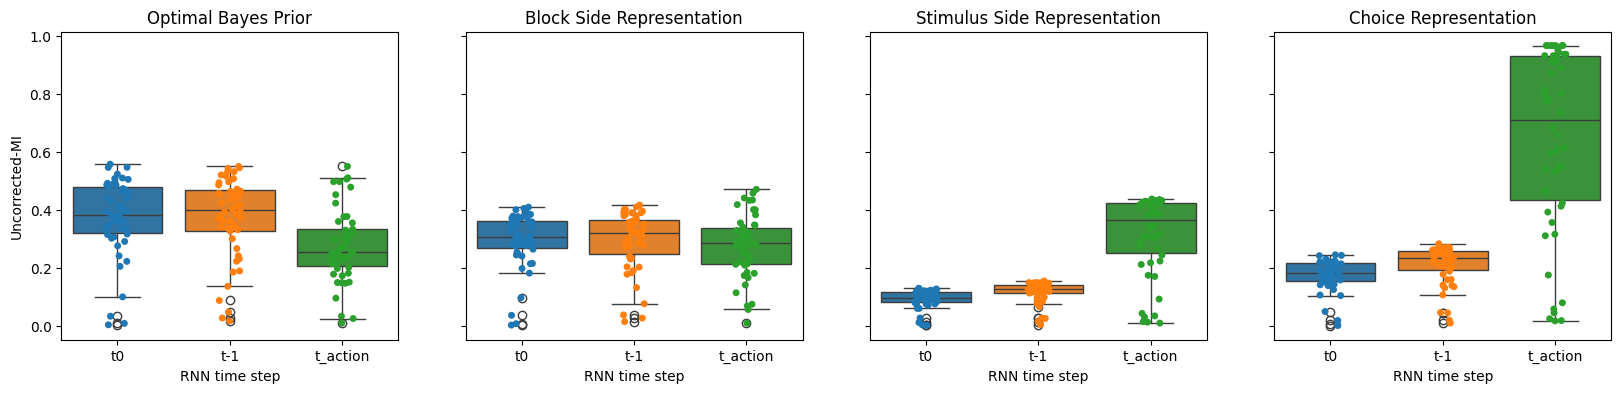

In [315]:
plot_all(session_data,[],False)

In [316]:
# now for all the partial decompositions
# maybe just compute coinformation
# what about correct vs incorrect trials

In [317]:
correct_trials = session_data[(session_data['correct_trial_dt']==1)]
incorrect_trials = session_data[(session_data['correct_trial_dt']==0)]

bayes_indices_correct = np.asarray([session_data[(session_data['action_taken']==1) & (session_data['correct_trial_dt']==1)].index]).reshape(-1,)
bayes_indices_incorrect = np.asarray([session_data[(session_data['action_taken']==1) & (session_data['correct_trial_dt']==0)].index]).reshape(-1,)

In [318]:
# run the same analysis as before, separating out correct and incorrect trials


In [91]:
correct_trials = session_data[(session_data['correct_trial_dt']==1)]
incorrect_trials = session_data[(session_data['correct_trial_dt']==0)]

bayes_indices_correct = np.asarray([session_data[(session_data['action_taken']==1) & (session_data['correct_trial_dt']==1)].index]).reshape(-1,)
bayes_indices_incorrect = np.asarray([session_data[(session_data['action_taken']==1) & (session_data['correct_trial_dt']==0)].index]).reshape(-1,)

bayes_idx_correct = np.concatenate([np.where(action_data.index == value)[0] for value in bayes_indices_correct])
bayes_idx_incorrect = np.concatenate([np.where(action_data.index == value)[0] for value in bayes_indices_incorrect])

In [92]:
bayes_idx_correct

array([   0,    1,    2, ..., 5007, 5012, 5013], dtype=int64)

  0%|          | 0/50 [00:00<?, ?it/s]

100%|██████████| 50/50 [00:00<00:00, 395.41it/s]


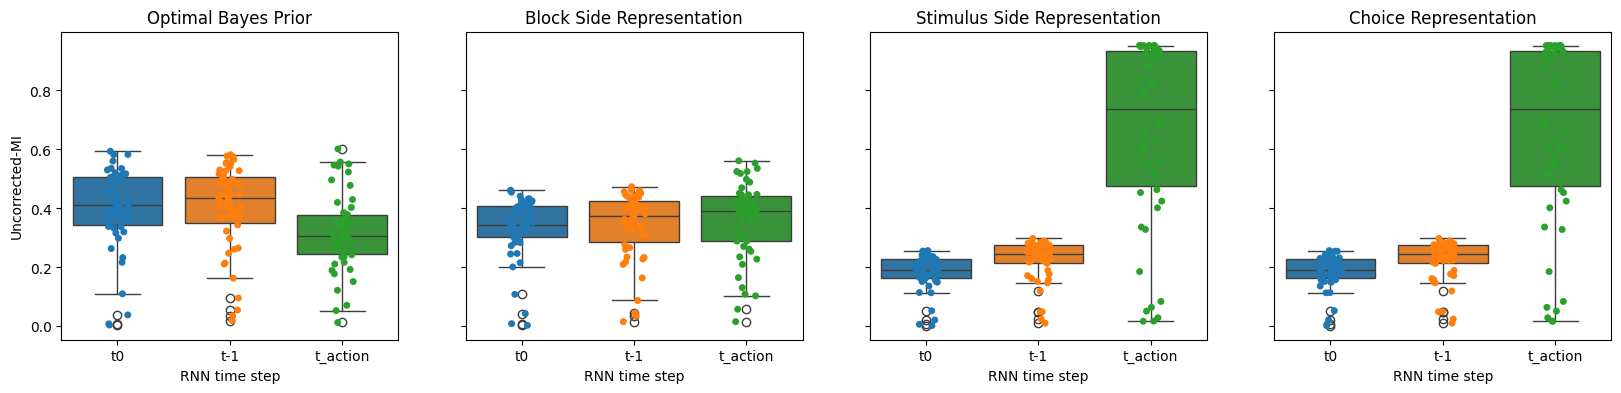

In [320]:
plot_all(correct_trials, bayes_idx_correct, True)

100%|██████████| 50/50 [00:00<00:00, 991.00it/s]


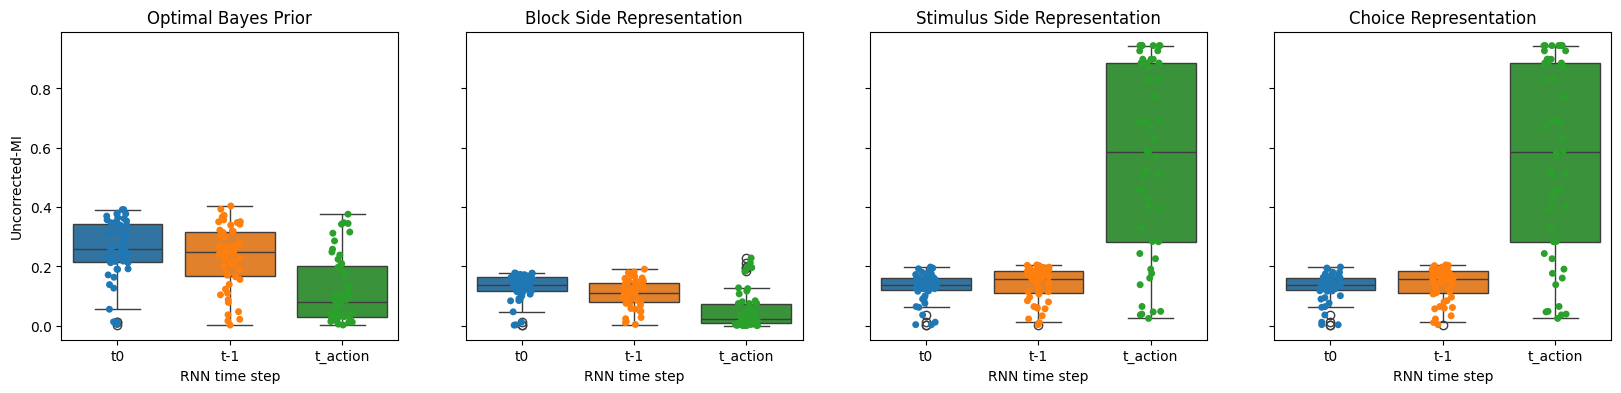

In [321]:
plot_all(incorrect_trials, bayes_idx_incorrect, True)

In [322]:
# run PID
import itertools

In [323]:
def generate_source_ids(number_of_neurons):
    combinations_neuronids=[]
    for x in itertools.combinations(range(number_of_neurons), 2):
        combinations_neuronids.append([x[0], x[1]])
    
    combinations_neuronids = np.asarray(combinations_neuronids)
    return combinations_neuronids


In [334]:
def compute_information_decomposition(decoding_variable, neural_data):
    # always same region
    # neural data is in neurons x trials
    targets = decoding_variable
    sources = generate_source_ids(neural_data.shape[0])

    pid_information = np.zeros((len(sources), 4)) # neuronsC2 x 4
    coinformation_data = np.zeros((len(sources), 4)) # neuronsC2 x 4

    for idx in tqdm(range(len(sources)), desc="Running for all sources",leave=False):
        s1 = sources[idx][0]
        s2 = sources[idx][1]
        X1 = np.asarray(neural_data[s1, :], dtype=np.int32)
        X2 = np.asarray(neural_data[s2, :], dtype=np.int32)
        Y = np.asarray(targets, dtype=np.int32)
        u1, u2, red, syn = compute_pid_unbiased(Y, X1, X2)
        coinfo, mi_yx1x2, mi_yx1, mi_yx2 = coinformation(Y, X1, X2)
        pid_information[idx, :] = u1, u2, red, syn
        coinformation_data[idx,:] = mi_yx1, mi_yx2, coinfo, mi_yx1x2


    # now to organize this?
    # nah, unique information would just be the mean of the first two
    # red and syn  are fine
    # yx1 and yx2 mutual info are also similar to UI
    # the other two are trivariate

    return pid_information, coinformation_data

In [356]:
q = np.hstack([pid_information, coinformation_data])
q.shape

(1225, 8)

(1225,)

In [383]:
# run all PID

# organize everything; discretize separately, and then make plots
# all decisions

def get_all_pid(session_data,indices,subset_bayes=False):

    iloc = np.where((session_data['action_taken'] == 1)==True)[0]
    t_1 = session_data.iloc[iloc-1][['block_side', 'signed_trial_strength', 'action_side','trial_side','correct_action_taken','hidden_state','left_stimulus','right_stimulus']]

    t_0 = session_data.loc[session_data['trial_start'] == 1,['block_side', 'signed_trial_strength', 'action_side','trial_side','correct_action_taken','hidden_state','left_stimulus','right_stimulus']]
    t_0['signed_trial_strength'] /= t_0['signed_trial_strength'].max()

    t_end = session_data.loc[session_data['action_taken'] == 1,['block_side', 'signed_trial_strength', 'action_side','trial_side','correct_action_taken','hidden_state','left_stimulus','right_stimulus']]
    t_end['signed_trial_strength'] /= t_end['signed_trial_strength'].max()

    hidden_state_t_0 = np.concatenate(t_0['hidden_state'].values)
    hidden_state_t_1 = np.concatenate(t_1['hidden_state'].values)
    hidden_state_t_end = np.concatenate(t_end['hidden_state'].values)

    # discretize
    discretized_hidden_state_t_0 = discretize_hidden_state(hidden_state_t_0.T)
    discretized_hidden_state_t_1 = discretize_hidden_state(hidden_state_t_1.T)
    discretized_hidden_state_t_end = discretize_hidden_state(hidden_state_t_end.T)


    # compute all mutual informations

    # for t0 and t-1, no action

    
    pid_information, coinformation_data = compute_information_decomposition(t_0['trial_side'].values,  discretized_hidden_state_t_0)
    trial_side_t0 = np.hstack([pid_information, coinformation_data])


    pid_information, coinformation_data = compute_information_decomposition(t_0['block_side'].values,  discretized_hidden_state_t_0)
    block_side_t0 = np.hstack([pid_information, coinformation_data])
    

    pid_information, coinformation_data = compute_information_decomposition(t_1['trial_side'].values,  discretized_hidden_state_t_1)
    trial_side_t1 = np.hstack([pid_information, coinformation_data])

    pid_information, coinformation_data = compute_information_decomposition(t_1['block_side'].values,  discretized_hidden_state_t_1)
    block_side_t1 = np.hstack([pid_information, coinformation_data])


    # for tend, compute all


    pid_information, coinformation_data = compute_information_decomposition(t_end['trial_side'].values,  discretized_hidden_state_t_end)
    trial_side_tend = np.hstack([pid_information, coinformation_data])

    pid_information, coinformation_data = compute_information_decomposition(t_end['block_side'].values,  discretized_hidden_state_t_end)
    block_side_tend = np.hstack([pid_information, coinformation_data])


    # action

    pid_information, coinformation_data = compute_information_decomposition(t_end['action_side'].values,  discretized_hidden_state_t_0)
    action_side_t0 = np.hstack([pid_information, coinformation_data])

    pid_information, coinformation_data = compute_information_decomposition(t_end['action_side'].values,  discretized_hidden_state_t_1)
    action_side_t1 = np.hstack([pid_information, coinformation_data])

    pid_information, coinformation_data = compute_information_decomposition(t_end['action_side'].values,  discretized_hidden_state_t_end)
    action_side_tend = np.hstack([pid_information, coinformation_data])


    # compute bayes and hidden state for all

    bayes_signal = np.asarray(signal.data.numpy()>=0.5, dtype=int)
    if subset_bayes:
        bayes_signal = bayes_signal[indices]
    
    pid_information, coinformation_data = compute_information_decomposition(bayes_signal,  discretized_hidden_state_t_0)
    bayesian_t0 = np.hstack([pid_information, coinformation_data])

    pid_information, coinformation_data = compute_information_decomposition(bayes_signal,  discretized_hidden_state_t_1)
    bayesian_t1 = np.hstack([pid_information, coinformation_data])

    pid_information, coinformation_data = compute_information_decomposition(bayes_signal,  discretized_hidden_state_t_end)
    bayesian_tend = np.hstack([pid_information, coinformation_data])

    # compute means for different catagories, and then plot them
    # we could do this stacking, but maybe after computing the means

    trial_side_t0_mean = np.mean(trial_side_t0, axis=0)
    block_side_t0_mean = np.mean(block_side_t0, axis=0)
    trial_side_t1_mean = np.mean(trial_side_t1, axis=0)
    block_side_t1_mean = np.mean(block_side_t1, axis=0)
    trial_side_tend_mean = np.mean(trial_side_tend, axis=0)
    block_side_tend_mean = np.mean(block_side_tend, axis=0)
    action_side_t0_mean = np.mean(action_side_t0, axis=0)
    action_side_t1_mean = np.mean(action_side_t1, axis=0)
    action_side_tend_mean = np.mean(action_side_tend, axis=0)
    bayesian_t0_mean = np.mean(bayesian_t0, axis=0)
    bayesian_t1_mean = np.mean(bayesian_t1, axis=0)
    bayesian_tend_mean = np.mean(bayesian_tend, axis=0)

    trial_side_t0_std = np.std(trial_side_t0, axis=0)
    block_side_t0_std = np.std(block_side_t0, axis=0)
    trial_side_t1_std = np.std(trial_side_t1, axis=0)
    block_side_t1_std = np.std(block_side_t1, axis=0)
    trial_side_tend_std = np.std(trial_side_tend, axis=0)
    block_side_tend_std = np.std(block_side_tend, axis=0)
    action_side_t0_std = np.std(action_side_t0, axis=0)
    action_side_t1_std = np.std(action_side_t1, axis=0)
    action_side_tend_std = np.std(action_side_tend, axis=0)
    bayesian_t0_std = np.std(bayesian_t0, axis=0)
    bayesian_t1_std = np.std(bayesian_t1, axis=0)
    bayesian_tend_std = np.std(bayesian_tend, axis=0)

    # maybe it makes more sense to plot the activity of each unit rather than the 


    Bayesian_mean_stack = np.stack([bayesian_t0_mean,bayesian_t1_mean,bayesian_tend_mean],axis=1)
    Block_side_mean_stack = np.stack([block_side_t0_mean,block_side_t1_mean,block_side_tend_mean],axis=1)
    Stim_side_mean_stack = np.stack([trial_side_t0_mean,trial_side_t1_mean,trial_side_tend_mean],axis=1)
    Action_side_mean_stack = np.stack([action_side_t0_mean,action_side_t1_mean,action_side_tend_mean],axis=1)


    Bayesian_std_stack = np.stack([bayesian_t0_std,bayesian_t1_std,bayesian_tend_std],axis=1)
    Block_side_std_stack = np.stack([block_side_t0_std,block_side_t1_std,block_side_tend_std],axis=1)
    Stim_side_std_stack = np.stack([trial_side_t0_std,trial_side_t1_std,trial_side_tend_std],axis=1)
    Action_side_std_stack = np.stack([action_side_t0_std,action_side_t1_std,action_side_tend_std],axis=1)

    fig, ax = plt.subplots(figsize=(20,4), ncols=4, sharey=True, sharex=True)

    ax[0].bar(np.arange(3)-0.25,Bayesian_mean_stack[2,:],width=0.25, yerr=Bayesian_std_stack[2,:]/2)
    ax[0].bar(np.arange(3),Bayesian_mean_stack[3,:],width=0.25, yerr=Bayesian_std_stack[3,:]/2)
    ax[0].bar(np.arange(3)+0.25,Bayesian_mean_stack[-1,:],width=0.25, yerr=Bayesian_std_stack[-1,:]/2)
    ax[0].set_xticks(np.arange(3),labels=['t0','t-1','t_action'])
    ax[0].set_xlabel('RNN time step')
    ax[0].set_ylabel('Bits')
    ax[0].set_title('Optimal Bayes Prior Representation')


    ax[1].bar(np.arange(3)-0.25,Block_side_mean_stack[2,:],width=0.25, yerr=Block_side_std_stack[2,:]/2)
    ax[1].bar(np.arange(3),Block_side_mean_stack[3,:],width=0.25, yerr=Block_side_std_stack[3,:]/2)
    ax[1].bar(np.arange(3)+0.25,Block_side_mean_stack[-1,:],width=0.25, yerr=Block_side_std_stack[-1,:]/2)
    ax[1].set_xticks(np.arange(3),labels=['t0','t-1','t_action'])
    ax[1].set_xlabel('RNN time step')
    ax[1].set_title('Block Side Representation')


    ax[2].bar(np.arange(3)-0.25,Stim_side_mean_stack[2,:],width=0.25, yerr=Stim_side_std_stack[2,:]/2)
    ax[2].bar(np.arange(3),Stim_side_mean_stack[3,:],width=0.25, yerr=Stim_side_std_stack[3,:]/2)
    ax[2].bar(np.arange(3)+0.25,Stim_side_mean_stack[-1,:],width=0.25, yerr=Stim_side_std_stack[-1,:]/2)
    ax[2].set_xticks(np.arange(3),labels=['t0','t-1','t_action'])
    ax[2].set_xlabel('RNN time step')
    ax[2].set_title('Stim Side Representation')



    ax[3].bar(np.arange(3)-0.25,Action_side_mean_stack[2,:],width=0.25, yerr=Action_side_std_stack[2,:]/2,label='Redundancy')
    ax[3].bar(np.arange(3),Action_side_mean_stack[3,:],width=0.25, yerr=Action_side_std_stack[3,:]/2,label='Synergy')
    ax[3].bar(np.arange(3)+0.25,Action_side_mean_stack[-1,:],width=0.25, yerr=Action_side_std_stack[-1,:]/2,label='total MI')
    ax[3].set_xticks(np.arange(3),labels=['t0','t-1','t_action'])
    ax[3].set_xlabel('RNN time step')
    ax[3].set_title('Choice Side Representation')

    plt.legend()
    
    return (Bayesian_mean_stack, Block_side_mean_stack, Stim_side_mean_stack, Action_side_mean_stack, Bayesian_std_stack, Block_side_std_stack, Stim_side_std_stack, Action_side_std_stack)

In [359]:
(Bayesian_mean_stack, Block_side_mean_stack, Stim_side_mean_stack, Action_side_mean_stack, Bayesian_std_stack, Block_side_std_stack, Stim_side_std_stack, Action_side_std_stack) = get_all_pid(session_data, [], False)

100%|██████████| 50/50 [00:00<00:00, 914.68it/s]


In [363]:
data = (Bayesian_mean_stack, Block_side_mean_stack, Stim_side_mean_stack, Action_side_mean_stack, Bayesian_std_stack, Block_side_std_stack, Stim_side_std_stack, Action_side_std_stack)

In [365]:
with open('../models/pids_all.pkl','wb') as f:
    pkl.dump(data,f)

In [ ]:
#u1, u2, red, syn,mi_yx1, mi_yx2, coinfo, mi_yx1x2 is the ordering
# red: 2
# syn: 3

Bayesian_mean_stack.shape

(8, 3)

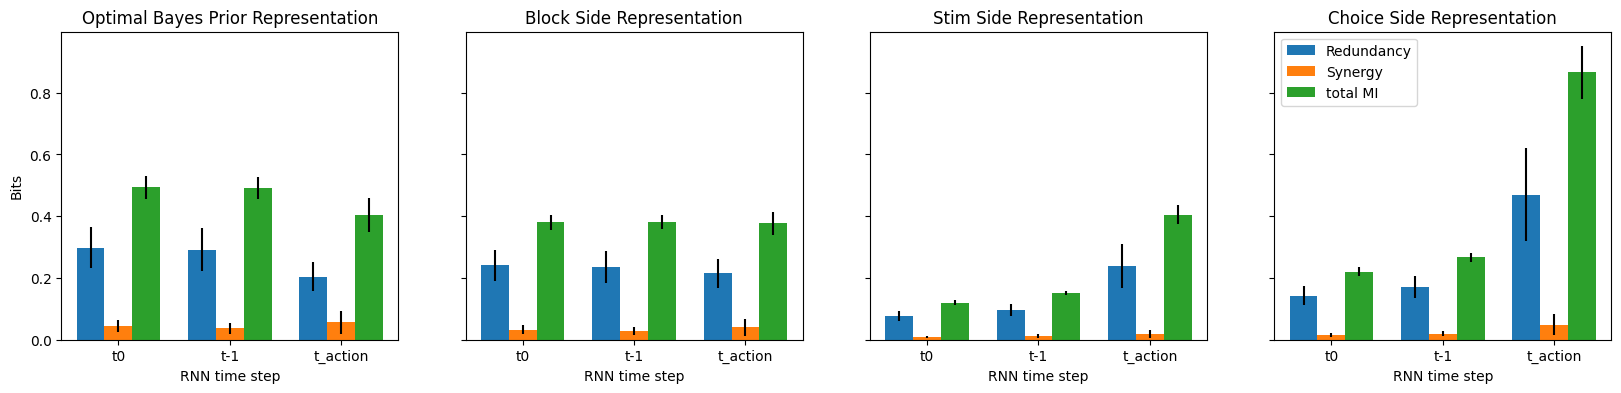

  0%|          | 0/50 [00:00<?, ?it/s]

100%|██████████| 50/50 [00:00<00:00, 802.37it/s]


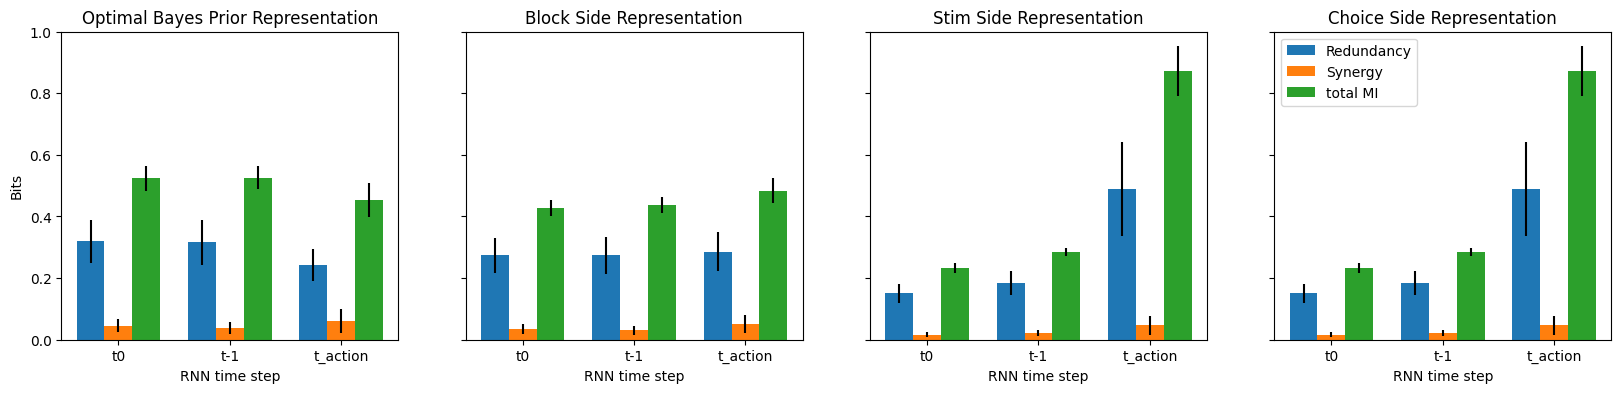

In [385]:
(Bayesian_mean_stack, Block_side_mean_stack, Stim_side_mean_stack, Action_side_mean_stack, Bayesian_std_stack, Block_side_std_stack, Stim_side_std_stack, Action_side_std_stack) = get_all_pid(correct_trials, bayes_idx_correct, True)

100%|██████████| 50/50 [00:00<00:00, 1129.23it/s]


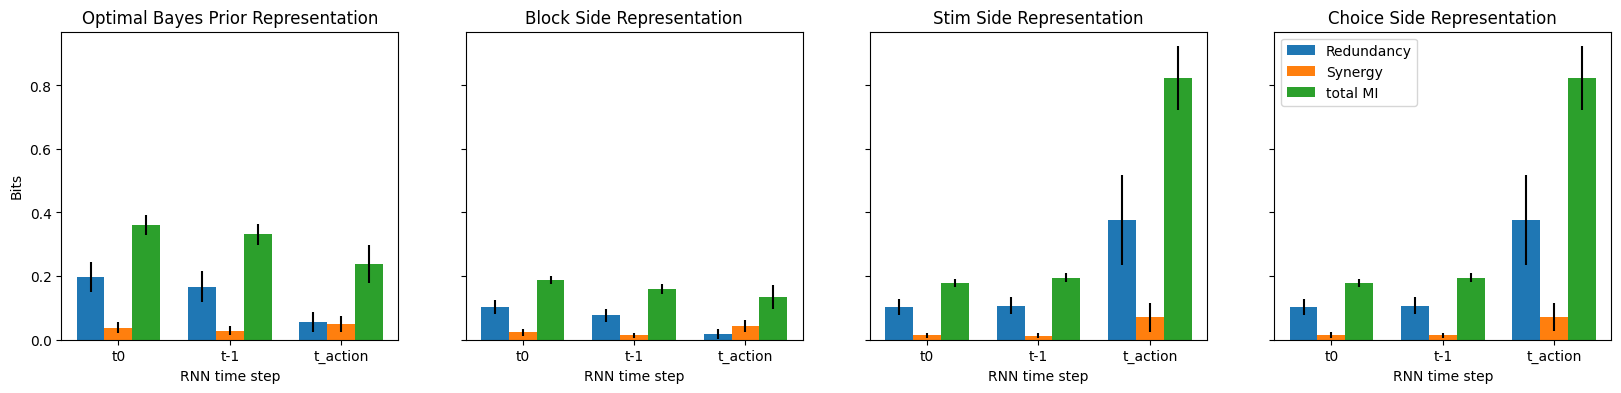

In [384]:
(Bayesian_mean_stack, Block_side_mean_stack, Stim_side_mean_stack, Action_side_mean_stack, Bayesian_std_stack, Block_side_std_stack, Stim_side_std_stack, Action_side_std_stack) = get_all_pid(incorrect_trials, bayes_idx_incorrect, True)

In [ ]:
# stimulus values at t-1
# different schemes for MI (4, 5 or more)
# modular training


In [61]:
# stimulus values plot and rnn-action taken

iloc = np.where((session_data['action_taken'] == 1)==True)[0]
t_1 = session_data.iloc[iloc-1][['block_side', 'signed_trial_strength', 'action_side','trial_side','correct_action_taken','hidden_state','left_stimulus','right_stimulus','rnn_step_index']]

t_0 = session_data.loc[session_data['trial_start'] == 1,['block_side', 'signed_trial_strength', 'action_side','trial_side','correct_action_taken','hidden_state','left_stimulus','right_stimulus','rnn_step_index']]
t_0['signed_trial_strength'] /= t_0['signed_trial_strength'].max()

t_end = session_data.loc[session_data['action_taken'] == 1,['block_side', 'signed_trial_strength', 'action_side','trial_side','correct_action_taken','hidden_state','left_stimulus','right_stimulus','rnn_step_index']]
t_end['signed_trial_strength'] /= t_end['signed_trial_strength'].max()

In [49]:
zero_t1 = (t_1['left_stimulus']==0) & (t_1['right_stimulus']==0)

In [58]:
non_zero_t1 =(t_1['left_stimulus']!=0) & (t_1['right_stimulus']!=0)

In [54]:
t_1[zero_t1]['rnn_step_index'].describe()

count    4175.0
mean        1.0
std         0.0
min         1.0
25%         1.0
50%         1.0
75%         1.0
max         1.0
Name: rnn_step_index, dtype: float64

In [60]:
t_1[non_zero_t1]['rnn_step_index'].unique()

array([2., 4., 5., 3., 6., 7.], dtype=float16)

<Axes: >

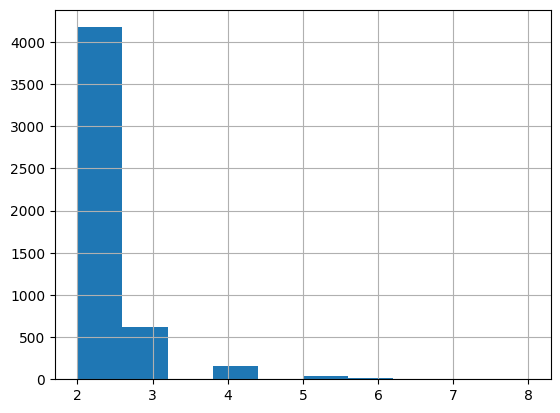

In [64]:
t_end['rnn_step_index'].hist()

In [15]:
from sklearn.preprocessing import KBinsDiscretizer

In [14]:
def discretize_hidden_state(hidden_state, n_bins=4):
    """
    Discretize the hidden state into equipopulated bins

    Args:
        hidden_state (np.array): activations for neurons x trials
        method (str, optional): how to determine the percenille. 
                                Defaults to 'neuron'. Calculate the percentile per neuron
                                Other options: 'all': Calculate the percentile based on the entire dataset
    """
    
    
    discrete_data = np.zeros((hidden_state.shape[0], hidden_state.shape[1]))
    # discretize per recorded neuron
    for idx in tqdm(range(hidden_state.shape[0])):

        row = hidden_state[idx, :]
        #bin_edges = np.percentile(row, [20,40,60,80])
        # set bin edges to 4 parts
        #bin_edges = np.percentile(row, [25,50,75])
        #discrete_data[idx, :] = np.digitize(row, bin_edges)
        discrete_row, bin_edges_p = pd.qcut(row, q=n_bins, labels=False, duplicates='drop', retbins=True)
        discrete_data[idx, :] = discrete_row
    
    discrete_data = np.nan_to_num(discrete_data, nan=0)
    return discrete_data

In [79]:
X = np.random.rand(5,100)

In [12]:
import seaborn as sns

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import KBinsDiscretizer


In [146]:
X = hidden_state_t_0

In [ ]:
discretizer = KBinsDiscretizer(
                n_bins=5, 
                encode='ordinal', 
                strategy='quantile'
            )
discretized_X = discretizer.fit_transform(X)


In [171]:
X.shape, discretized_X.shape

((5014, 50), (5014, 50))

In [166]:
X_alt = discretize_hidden_state(X.T,5)

100%|██████████| 50/50 [00:00<00:00, 1148.28it/s]


In [130]:
from sklearn.model_selection import KFold

In [127]:


def find_optimal_discretization_train_test_split(X, Y, max_bins=20, subset_ratio=0.5, random_state=42):
    """
    Find optimal discretization for multiple features.
    
    Parameters:
    -----------
    X : array-like of shape (n_timepoints, n_neurons)
        Input features to be discretized
    Y : array-like of shape (n_timepoints, )
        Target variable
    max_bins : int, default=20
        Maximum number of bins to consider
    subset_ratio : float, default=0.5
        Proportion of data to use for finding optimal bins
    random_state : int, default=42
        Random seed for reproducibility
    
    Returns:
    --------
    dict : A dictionary containing:
        - 'optimal_bins': List of optimal bin counts for each feature
        - 'mutual_info_scores': List of mutual information scores for each feature
        - 'full_dataset_mi': Mutual information computed on full dataset for each feature
    """
    # Flatten Y if it's a 2D array
    Y = Y.ravel()
    
    # Ensure X is 2D
    
    
    # Split the data into subset for bin optimization and full dataset
    X_subset, X_full, Y_subset, Y_full = train_test_split(
        X, Y, 
        train_size=subset_ratio, 
        random_state=random_state
    )
    
    # Store results for each feature
    
    mi_scores_list = []
    mi_test_scores = []

    # discretize X first
    for n_bins in tqdm(range(2, max_bins + 1)):
        
        discretizer = KBinsDiscretizer(
                    n_bins=n_bins, 
                    encode='ordinal', 
                    strategy='quantile'
                )
        # this discretizes each feature by itself
        discretized_X_subset = discretizer.fit_transform(X_subset)
        mi_scores = []        
        for feature_idx in range(X.shape[1]):

        
            X_subset_feature = discretized_X_subset[:, feature_idx]
                        
            # Store MI scores for different bin counts
            # Calculate mutual information on subset
            
            mi_scores.append(MI(X_subset_feature, Y_subset))
        mi_scores = np.asarray(mi_scores) # the idea is to find the best discretization for all features
        mi_scores_list.append(np.mean(mi_scores))
    
    # Find the optimal number of bins from subset
    optimal_bins = np.argmax(mi_scores_list) + 2  # +2 because we started from 2 bins
        
    # Compute mutual information on full dataset with optimal bins
    full_discretizer = KBinsDiscretizer(
            n_bins=optimal_bins, 
            encode='ordinal', 
            strategy='quantile'
        )
    
    X_full_discretized = full_discretizer.fit_transform(X_full)
    
    for feature_idx in range(X.shape[1]):
        
        mi_test_scores.append(MI(X_full_discretized[:,feature_idx], Y_full))
    
    return np.asarray(mi_scores_list), np.asarray(mi_test_scores), optimal_bins

In [128]:
def find_optimal_discretization_kfold(X, Y, max_bins=20, n_folds=5, random_state=42):
    """
    Find optimal discretization for multiple features.
    
    Parameters:
    -----------
    X : array-like of shape (n_timepoints, n_neurons)
        Input features to be discretized
    Y : array-like of shape (n_timepoints, )
        Target variable
    max_bins : int, default=20
        Maximum number of bins to consider
    n_folds : int, default=5
        Number of folds
    random_state : int, default=42
        Random seed for reproducibility
    
    Returns:
    --------
    dict : A dictionary containing:
        - 'optimal_bins': List of optimal bin counts for each feature
        - 'mutual_info_scores': List of mutual information scores for each feature
        - 'full_dataset_mi': Mutual information computed on full dataset for each feature
    """
    # Flatten Y if it's a 2D array
    Y = Y.ravel()
    
    # Ensure X is 2D
    
    
    # Split the data into subset for bin optimization and full dataset
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=random_state)
    
    mi_fold_test = []
    mi_fold_train = []
    optimal_bin_list = []
    for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X)):
        X_train, X_val = X[train_idx,:], X[val_idx,:]
        y_train, y_val = Y[train_idx], Y[val_idx]
        mi_scores_list = []

        # discretize X_train first, try different bin sizes
        for n_bins in tqdm(range(2, max_bins + 1)):
            discretizer = KBinsDiscretizer(
                    n_bins=n_bins, 
                    encode='ordinal', 
                    strategy='quantile'
                )
            # this discretizes each feature by itself
            discretized_X_subset = discretizer.fit_transform(X_train)
            mi_scores = []       
            for feature_idx in range(X.shape[1]):
        
                X_subset_feature = discretized_X_subset[:, feature_idx]
                # Store MI scores for different bin counts
                            
                # Calculate mutual information on subset
                mi_scores.append(MI(X_subset_feature, y_train))
            mi_scores = np.asarray(mi_scores) # the idea is to find the best discretization for all features
            mi_scores_list.append(np.mean(mi_scores))
            
        mi_fold_train.append(mi_scores_list)
    
        # Find the optimal number of bins from subset
        optimal_bins = np.argmax(mi_scores_list) + 2  # +2 because we started from 2 bins
        
        # Compute mutual information on full dataset with optimal bins
        full_discretizer = KBinsDiscretizer(
                n_bins=optimal_bins, 
                encode='ordinal', 
                strategy='quantile'
            )
        optimal_bin_list.append(optimal_bins)
        X_full_discretized = full_discretizer.fit_transform(X_val)
        mi_test_scores = []
        for feature_idx in range(X.shape[1]):
            mi_test_scores.append(MI(X_full_discretized[:,feature_idx], y_val))

        mi_fold_test.append(mi_test_scores)


    return np.asarray(mi_fold_train), np.asarray(mi_fold_test), np.asarray(optimal_bin_list)

In [271]:

hidden_state_t_end = np.concatenate(t_end['hidden_state'].values)

In [272]:
Y1 = t_end['action_side'].values
Y2 = t_end['trial_side'].values

In [286]:
mi_scores_action, test_scores_action = find_optimal_discretization_train_test_split(hidden_state_t_end, Y1)
mi_scores_trial, test_scores_trial = find_optimal_discretization_train_test_split(hidden_state_t_end, Y2)

100%|██████████| 19/19 [00:01<00:00, 10.78it/s]


<Axes: >

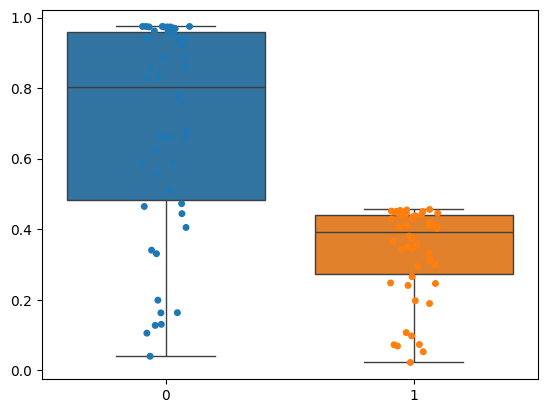

In [268]:
sns.boxplot(np.stack([test_scores_action, test_scores_trial], axis=1))
sns.stripplot(np.stack([test_scores_action, test_scores_trial], axis=1))

In [287]:
mi_scores_action_fold, test_scores_action_fold = find_optimal_discretization_kfold(hidden_state_t_end, Y1)
mi_scores_trial_fold, test_scores_trial_fold = find_optimal_discretization_kfold(hidden_state_t_end, Y2)

100%|██████████| 19/19 [00:02<00:00,  6.87it/s]


In [288]:
q1 = np.mean(test_scores_action_fold, axis=0)
q2 = np.mean(test_scores_trial_fold, axis=0)

<Axes: >

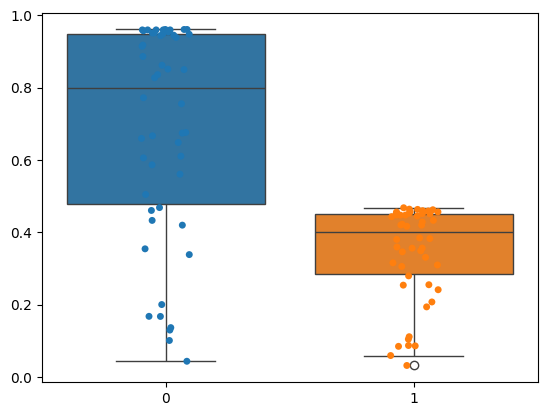

In [289]:
sns.boxplot(np.stack([q1, q2], axis=1))
sns.stripplot(np.stack([q1, q2], axis=1))

<Axes: >

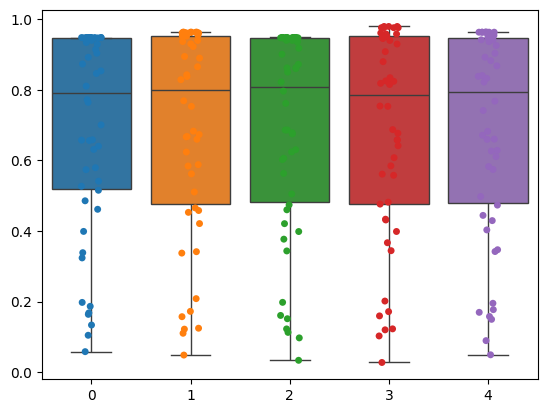

In [301]:
sns.boxplot(test_scores_action_fold.T)
sns.stripplot(test_scores_action_fold.T)

In [308]:
session_data

,rnn_step_within_session,trial_within_session,block_index,trial_index,rnn_step_index,block_side,trial_side,trial_strength,trial_start,trial_end,...,action_side,correct_action_taken,session_index,1_back_correct,2_back_correct,3_back_correct,signed_trial_strength,concordant_trial,correct_trial_dt,trial_side_orthogonal
0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.5,1.0,NaN,...,NaN,NaN,0,NaN,NaN,NaN,0.5,True,1.0,0.418457
1,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.5,NaN,NaN,...,NaN,NaN,0,NaN,NaN,NaN,0.5,True,1.0,0.418457
2,2.0,0.0,0.0,0.0,2.0,1.0,1.0,0.5,NaN,NaN,...,NaN,NaN,0,NaN,NaN,NaN,0.5,True,1.0,0.418457
3,3.0,0.0,0.0,0.0,3.0,1.0,1.0,0.5,NaN,1.0,...,1.0,1.0,0,NaN,NaN,NaN,0.5,True,1.0,0.418457
4,4.0,1.0,0.0,1.0,0.0,1.0,1.0,1.5,1.0,NaN,...,NaN,NaN,0,NaN,NaN,NaN,1.5,True,1.0,0.418457
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16190,16192.0,5012.0,99.0,31.0,2.0,-1.0,1.0,2.5,NaN,1.0,...,1.0,1.0,0,0.0,0.0,0.0,2.5,False,1.0,1.582031
16191,16192.0,5012.0,99.0,32.0,0.0,-1.0,-1.0,1.5,1.0,NaN,...,NaN,NaN,0,NaN,NaN,NaN,-1.5,True,1.0,-0.418457
16192,16192.0,5012.0,99.0,32.0,1.0,-1.0,-1.0,1.5,NaN,NaN,...,NaN,NaN,0,NaN,NaN,NaN,-1.5,True,1.0,-0.418457
16193,16192.0,5012.0,99.0,32.0,2.0,-1.0,-1.0,1.5,NaN,NaN,...,NaN,NaN,0,NaN,NaN,NaN,-1.5,True,1.0,-0.418457


In [309]:
# stimulus values plot and rnn-action taken
signal = optimal_Bayesian(act=t_end['action_side'].values, side=t_end['trial_side'].values)
bayes_signal = np.asarray(signal.data.numpy()>=0.5, dtype=int)

t_0 = session_data.loc[session_data['trial_start'] == 1,['block_side', 'signed_trial_strength', 'action_side','trial_side','correct_action_taken','hidden_state','left_stimulus','right_stimulus','rnn_step_index','concordant_trial']]
t_0['signed_trial_strength'] /= t_0['signed_trial_strength'].max()

t_end = session_data.loc[session_data['action_taken'] == 1,['block_side', 'signed_trial_strength', 'action_side','trial_side','correct_action_taken','hidden_state','left_stimulus','right_stimulus','rnn_step_index','concordant_trial']]
t_end['signed_trial_strength'] /= t_end['signed_trial_strength'].max()
t_end['Bayes'] = bayes_signal

iloc = np.where((session_data['action_taken'] == 1)==True)[0]
t_1 = session_data.iloc[iloc-1][['block_side', 'signed_trial_strength', 'action_side','trial_side','correct_action_taken','hidden_state','left_stimulus','right_stimulus','rnn_step_index','concordant_trial']]
t_1['action_side'] = t_end['action_side'].values
t_1['Bayes'] = bayes_signal
t_1_non_zero = t_1.loc[(t_1['right_stimulus']!=0) | (t_1['left_stimulus']!=0) ]


# now for t_end for zero contrast trials, split by correct and incorrect choices
t_zero_contrast = t_end[t_end['signed_trial_strength']==0]

# find correct and incorrect indices



hidden_state_t_0 = np.concatenate(t_0['hidden_state'].values)
hidden_state_t_1 = np.concatenate(t_1['hidden_state'].values)
hidden_state_t_1_non_zero = np.concatenate(t_1_non_zero['hidden_state'].values)
hidden_state_t_end = np.concatenate(t_end['hidden_state'].values)
hidden_state_t_zero_contrast = np.concatenate(t_zero_contrast['hidden_state'].values)





In [ ]:
# correct_trials = session_data[(session_data['correct_trial_dt']==1)]
# incorrect_trials = session_data[(session_data['correct_trial_dt']==0)]

# bayes_indices_correct = np.asarray([session_data[(session_data['action_taken']==1) & (session_data['correct_trial_dt']==1)].index]).reshape(-1,)
# bayes_indices_incorrect = np.asarray([session_data[(session_data['action_taken']==1) & (session_data['correct_trial_dt']==0)].index]).reshape(-1,)

# bayes_idx_correct = np.concatenate([np.where(session_data.index == value)[0] for value in bayes_indices_correct])
# bayes_idx_incorrect = np.concatenate([np.where(session_data.index == value)[0] for value in bayes_indices_incorrect])

In [310]:

# this is correct, we can use the bayes idx to subset the prior signal

incorrect_zero_contrast = session_data.loc[(session_data['action_taken']==1) & (session_data['correct_trial_dt']==0) & (session_data['trial_strength']==0)].index
correct_zero_contrast = session_data.loc[(session_data['action_taken']==1) & (session_data['correct_trial_dt']==1) & (session_data['trial_strength']==0)].index

bayes_idx_correct_zero_contrast = np.concatenate([np.where(t_end.index == value)[0] for value in correct_zero_contrast])
bayes_idx_incorrect_zero_contrast = np.concatenate([np.where(t_end.index == value)[0] for value in incorrect_zero_contrast])



# this is for the traditional, correct vs incorrect actions

correct_trials = session_data[(session_data['correct_trial_dt']==1)]
incorrect_trials = session_data[(session_data['correct_trial_dt']==0)]

bayes_indices_correct = np.asarray([session_data[(session_data['action_taken']==1) & (session_data['correct_trial_dt']==1)].index]).reshape(-1,)
bayes_indices_incorrect = np.asarray([session_data[(session_data['action_taken']==1) & (session_data['correct_trial_dt']==0)].index]).reshape(-1,)

bayes_idx_correct = np.concatenate([np.where(action_data.index == value)[0] for value in bayes_indices_correct])
bayes_idx_incorrect = np.concatenate([np.where(action_data.index == value)[0] for value in bayes_indices_incorrect])


In [ ]:
#1. optimal discretization on t0 and t_end

def optimal_discrete_plots(t_0, hidden_state_t_0, t_end, hidden_state_t_end, signal, subset=False, indices=[]):

    target = t_end['action_side'].values
    _, test_scores_action_fold_tend, optimal_bins_tend_action = find_optimal_discretization_kfold(hidden_state_t_end, target)

    _, test_scores_action_fold_t0, optimal_bins_t0_action = find_optimal_discretization_kfold(hidden_state_t_0, target)

    
    target = t_0['trial_side'].values
    _, test_scores_trial_fold_t0, optimal_bins_t0_trial = find_optimal_discretization_kfold(hidden_state_t_0, target)

    target = t_end['trial_side'].values
    _, test_scores_trial_fold_tend, optimal_bins_tend_trial = find_optimal_discretization_kfold(hidden_state_t_end, target)


    # now for bayes
    if subset:
        signal = signal[indices]
        
    
    target =  np.asarray(signal.data.numpy()>=0.5, dtype=int)
    _, test_scores_bayesian_fold_t0, optimal_bins_t0_bayesian = find_optimal_discretization_kfold(hidden_state_t_0, target)
    _, test_scores_bayesian_fold_tend, optimal_bins_tend_bayesian = find_optimal_discretization_kfold(hidden_state_t_end, target)

    action_scores = np.stack([np.mean(test_scores_action_fold_t0, axis=0),np.mean(test_scores_action_fold_tend, axis=0)], axis=1)
    stimulus_scores = np.stack([np.mean(test_scores_trial_fold_t0, axis=0),np.mean(test_scores_trial_fold_tend, axis=0)], axis=1)
    bayesian_scores = np.stack([np.mean(test_scores_bayesian_fold_t0, axis=0),np.mean(test_scores_bayesian_fold_tend, axis=0)], axis=1)

    fig, ax = plt.subplots(ncols=3, figsize=(16, 4), sharey=True, sharex=True)

    sns.boxplot(bayesian_scores,ax=ax[0])
    sns.swarmplot(bayesian_scores,ax=ax[0])

    sns.boxplot(stimulus_scores,ax=ax[1])
    sns.swarmplot(stimulus_scores,ax=ax[1])

    sns.boxplot(action_scores,ax=ax[2])
    sns.swarmplot(action_scores,ax=ax[2])


    ax[0].set_xticks(np.arange(2),labels=['t0','t_action'])
    ax[0].set_xlabel('RNN time step')
    ax[0].set_ylabel('Uncorrected-MI')
    ax[0].set_title('Optimal Bayes Prior')
    ax[1].set_title('Stimulus')
    ax[2].set_title('Choice')
    

In [ ]:

print('choice representation')
target = t_end['action_side'].values
_, test_scores_action_fold_tend, optimal_bins_tend_action = find_optimal_discretization_kfold(hidden_state_t_end, target)

_, test_scores_action_fold_t0, optimal_bins_t0_action = find_optimal_discretization_kfold(hidden_state_t_0, target)

print('stimulus representation')
target = t_end['trial_side'].values
_, test_scores_trial_fold_tend, optimal_bins_tend_trial = find_optimal_discretization_kfold(hidden_state_t_end, target)

target = t_0['trial_side'].values
_, test_scores_trial_fold_t0, optimal_bins_t0_trial = find_optimal_discretization_kfold(hidden_state_t_0, target)


choice representation


100%|██████████| 19/19 [00:03<00:00,  5.10it/s]


stimulus representation


100%|██████████| 19/19 [00:03<00:00,  5.12it/s]


prior representation


100%|██████████| 19/19 [00:03<00:00,  5.12it/s]


In [143]:
print('prior representation')
target =  np.asarray(signal.data.numpy()>=0.5, dtype=int)
_, test_scores_bayesian_fold_t0, optimal_bins_t0_bayesian = find_optimal_discretization_kfold(hidden_state_t_0, target)
_, test_scores_bayesian_fold_tend, optimal_bins_tend_bayesian = find_optimal_discretization_kfold(hidden_state_t_end, target)

prior representation


100%|██████████| 19/19 [00:03<00:00,  5.16it/s]


Text(0.5, 1.0, 'Choice')

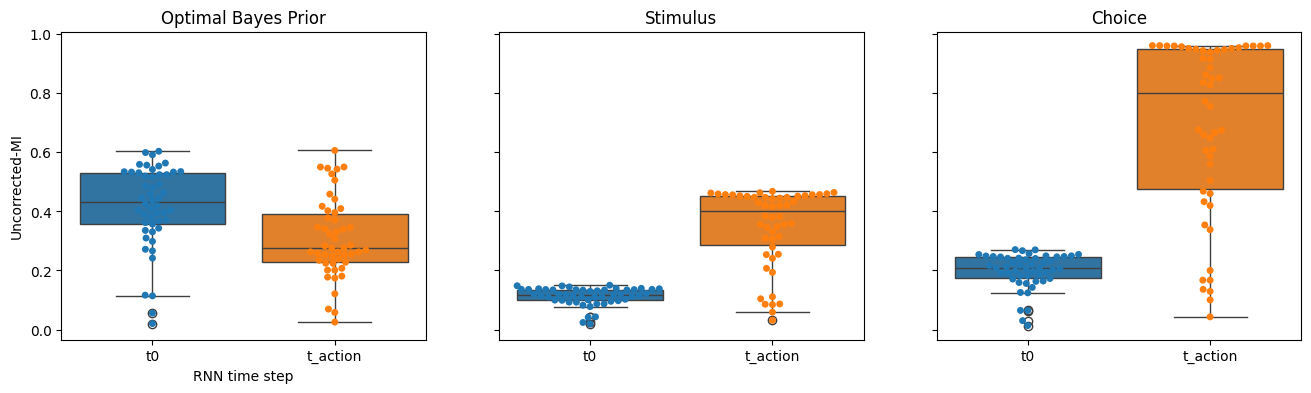

In [160]:
action_scores = np.stack([np.mean(test_scores_action_fold_t0, axis=0),np.mean(test_scores_action_fold_tend, axis=0)], axis=1)
stimulus_scores = np.stack([np.mean(test_scores_trial_fold_t0, axis=0),np.mean(test_scores_trial_fold_tend, axis=0)], axis=1)
bayesian_scores = np.stack([np.mean(test_scores_bayesian_fold_t0, axis=0),np.mean(test_scores_bayesian_fold_tend, axis=0)], axis=1)

fig, ax = plt.subplots(ncols=3, figsize=(16, 4), sharey=True, sharex=True)

sns.boxplot(bayesian_scores,ax=ax[0])
sns.swarmplot(bayesian_scores,ax=ax[0])

sns.boxplot(stimulus_scores,ax=ax[1])
sns.swarmplot(stimulus_scores,ax=ax[1])

sns.boxplot(action_scores,ax=ax[2])
sns.swarmplot(action_scores,ax=ax[2])


ax[0].set_xticks(np.arange(2),labels=['t0','t_action'])
ax[0].set_xlabel('RNN time step')
ax[0].set_ylabel('Uncorrected-MI')
ax[0].set_title('Optimal Bayes Prior')
ax[1].set_title('Stimulus')
ax[2].set_title('Choice')

In [202]:

print('choice representation')
target = t_end['action_side'].values
_, test_scores_action_fold_tend, optimal_bins_tend_action = find_optimal_discretization_kfold(hidden_state_t_end, target)

target = t_1_non_zero['action_side'].values
_, test_scores_action_fold_t1_non_zero, optimal_bins_t1_non_zero_action = find_optimal_discretization_kfold(hidden_state_t_1_non_zero, target)

print('stimulus representation')
target = t_end['trial_side'].values
_, test_scores_trial_fold_tend, optimal_bins_tend_trial = find_optimal_discretization_kfold(hidden_state_t_end, target)

target = t_1_non_zero['trial_side'].values
_, test_scores_trial_fold_t1_non_zero, optimal_bins_t1_non_zero_trial = find_optimal_discretization_kfold(hidden_state_t_1_non_zero, target)


print('prior representation')

target = t_1_non_zero['Bayes'].values
_, test_scores_bayesian_fold_t1_non_zero, optimal_bins_t1_non_zero_bayesian = find_optimal_discretization_kfold(hidden_state_t_1_non_zero, target)

target =  np.asarray(signal.data.numpy()>=0.5, dtype=int)
_, test_scores_bayesian_fold_tend, optimal_bins_tend_bayesian = find_optimal_discretization_kfold(hidden_state_t_end, target)

choice representation


100%|██████████| 19/19 [00:00<00:00, 22.38it/s]


stimulus representation


100%|██████████| 19/19 [00:00<00:00, 22.36it/s]


prior representation


100%|██████████| 19/19 [00:03<00:00,  5.05it/s]


Text(0.5, 1.0, 'Choice')

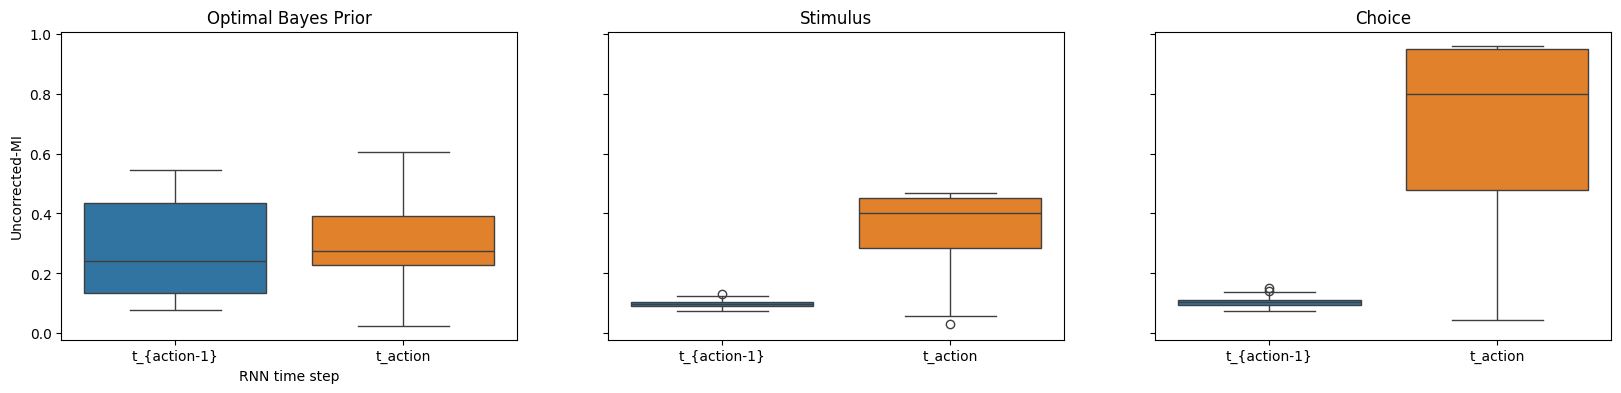

In [212]:
action_scores = np.stack([np.mean(test_scores_action_fold_t1_non_zero, axis=0),np.mean(test_scores_action_fold_tend, axis=0)], axis=1)
stimulus_scores = np.stack([np.mean(test_scores_trial_fold_t1_non_zero, axis=0),np.mean(test_scores_trial_fold_tend, axis=0)], axis=1)
bayesian_scores = np.stack([np.mean(test_scores_bayesian_fold_t1_non_zero, axis=0),np.mean(test_scores_bayesian_fold_tend, axis=0)], axis=1)

fig, ax = plt.subplots(ncols=3, figsize=(20, 4), sharey=True, sharex=True)

sns.boxplot(bayesian_scores,ax=ax[0])
# sns.swarmplot(bayesian_scores,ax=ax[0])

sns.boxplot(stimulus_scores,ax=ax[1])
# sns.swarmplot(stimulus_scores,ax=ax[1])

sns.boxplot(action_scores,ax=ax[2])
# sns.swarmplot(action_scores,ax=ax[2])


ax[0].set_xticks(np.arange(2),labels=['t_{action-1}','t_action'])
ax[0].set_xlabel('RNN time step')
ax[0].set_ylabel('Uncorrected-MI')
ax[0].set_title('Optimal Bayes Prior')
ax[1].set_title('Stimulus')
ax[2].set_title('Choice')

In [213]:

print('choice representation')
target = t_end['action_side'].values
_, test_scores_action_fold_tend, optimal_bins_tend_action = find_optimal_discretization_kfold(hidden_state_t_end, target)

target = t_1['action_side'].values
_, test_scores_action_fold_t1_non_zero, optimal_bins_t1_non_zero_action = find_optimal_discretization_kfold(hidden_state_t_1, target)

print('stimulus representation')
target = t_end['trial_side'].values
_, test_scores_trial_fold_tend, optimal_bins_tend_trial = find_optimal_discretization_kfold(hidden_state_t_end, target)

target = t_1['trial_side'].values
_, test_scores_trial_fold_t1_non_zero, optimal_bins_t1_non_zero_trial = find_optimal_discretization_kfold(hidden_state_t_1, target)


print('prior representation')

target = t_1['Bayes'].values
_, test_scores_bayesian_fold_t1_non_zero, optimal_bins_t1_non_zero_bayesian = find_optimal_discretization_kfold(hidden_state_t_1, target)

target =  np.asarray(signal.data.numpy()>=0.5, dtype=int)
_, test_scores_bayesian_fold_tend, optimal_bins_tend_bayesian = find_optimal_discretization_kfold(hidden_state_t_end, target)


choice representation


100%|██████████| 19/19 [00:03<00:00,  5.06it/s]


stimulus representation


100%|██████████| 19/19 [00:03<00:00,  5.13it/s]


prior representation


100%|██████████| 19/19 [00:03<00:00,  5.15it/s]


Text(0.5, 1.0, 'Choice')

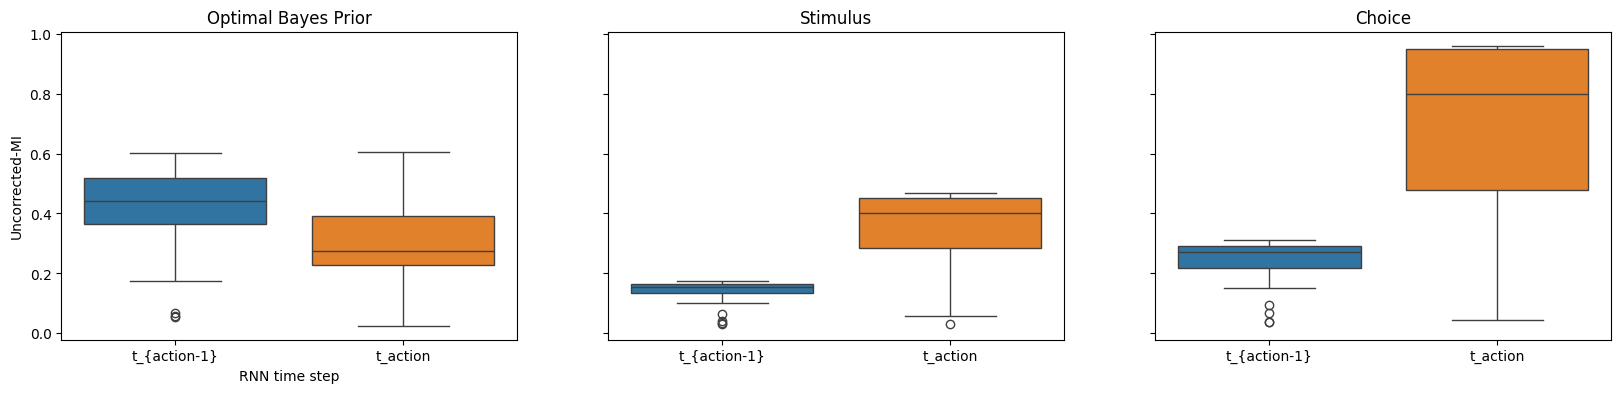

In [214]:
action_scores = np.stack([np.mean(test_scores_action_fold_t1_non_zero, axis=0),np.mean(test_scores_action_fold_tend, axis=0)], axis=1)
stimulus_scores = np.stack([np.mean(test_scores_trial_fold_t1_non_zero, axis=0),np.mean(test_scores_trial_fold_tend, axis=0)], axis=1)
bayesian_scores = np.stack([np.mean(test_scores_bayesian_fold_t1_non_zero, axis=0),np.mean(test_scores_bayesian_fold_tend, axis=0)], axis=1)

fig, ax = plt.subplots(ncols=3, figsize=(20, 4), sharey=True, sharex=True)

sns.boxplot(bayesian_scores,ax=ax[0])
# sns.swarmplot(bayesian_scores,ax=ax[0])

sns.boxplot(stimulus_scores,ax=ax[1])
# sns.swarmplot(stimulus_scores,ax=ax[1])

sns.boxplot(action_scores,ax=ax[2])
# sns.swarmplot(action_scores,ax=ax[2])


ax[0].set_xticks(np.arange(2),labels=['t_{action-1}','t_action'])
ax[0].set_xlabel('RNN time step')
ax[0].set_ylabel('Uncorrected-MI')
ax[0].set_title('Optimal Bayes Prior')
ax[1].set_title('Stimulus')
ax[2].set_title('Choice')

In [ ]:
##MI for zero contrast trials

# incorrect_zero_contrast
# correct_zero_contrast
# bayes_idx_correct_zero_contrast
# bayes_idx_incorrect_zero_contrast

Index([   61,    77,   105,   121,   127,   193,   223,   247,   263,   296,
       ...
       15836, 15888, 15897, 15916, 15934, 15940, 15943, 16047, 16084, 16119],
      dtype='int64', length=524)

In [236]:
hidden_state_t_zero_contrast_correct = np.concatenate(t_zero_contrast.loc[correct_zero_contrast]['hidden_state'].values)
hidden_state_t_zero_contrast_incorrect = np.concatenate(t_zero_contrast.loc[incorrect_zero_contrast]['hidden_state'].values)

In [307]:
hidden_state_t_zero_contrast_incorrect[1]

array([-0.12376762, -0.84945665,  0.47958117,  0.06470263,  0.07678592,
        0.13166889,  0.09602889,  0.01418415,  0.35763916, -0.18952894,
        0.41681487,  0.06706097, -0.16591341,  0.3416849 , -0.26426821,
       -0.6625865 ,  0.06996922,  0.6809027 ,  0.39420055, -0.53206893,
        0.20731441, -0.11745288,  0.18111976,  0.10096684,  0.10427128,
        0.08155866,  0.55691545, -0.00872778, -0.15385155, -0.18646828,
       -0.31692471, -0.13953759,  0.32470396,  0.12632057,  0.42056353,
       -0.08372302, -0.11668045,  0.12062335, -0.14195845, -0.37315336,
        0.42950357,  0.4231032 , -0.1600744 , -0.43276378,  0.5802846 ,
        0.09421769, -0.09925879,  0.19917203, -0.00186839,  0.37072534])

In [305]:
t_zero_contrast.loc[incorrect_zero_contrast]['trial_side'].values

array([ 1., -1., -1., -1.,  1.,  1., -1., -1., -1., -1.,  1.,  1.,  1.,
       -1., -1., -1., -1., -1., -1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
        1.,  1., -1.,  1.,  1., -1.,  1.,  1.,  1., -1., -1.,  1., -1.,
       -1., -1., -1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1., -1.,
       -1., -1., -1.,  1., -1., -1.,  1.,  1.,  1.,  1.,  1.,  1., -1.,
        1.,  1.,  1.,  1., -1.,  1.,  1., -1., -1., -1.,  1., -1., -1.,
       -1.,  1., -1., -1., -1., -1., -1., -1.,  1.,  1., -1.,  1., -1.,
       -1.,  1.,  1.,  1., -1.,  1.,  1., -1.,  1.,  1., -1., -1.,  1.,
       -1., -1., -1., -1., -1.,  1., -1.,  1.,  1.,  1.,  1.,  1.,  1.,
        1.,  1., -1., -1.,  1., -1.,  1.,  1.,  1., -1., -1.,  1., -1.,
        1.,  1.,  1.,  1.,  1.,  1.,  1., -1.,  1.,  1., -1.,  1.,  1.,
        1.,  1., -1., -1., -1.,  1., -1.,  1., -1., -1.,  1.,  1., -1.,
        1., -1., -1., -1.,  1., -1.,  1.,  1.,  1.,  1.,  1., -1., -1.,
       -1., -1.,  1.,  1.,  1.,  1., -1., -1., -1., -1., -1., -1

In [311]:
t_zero_contrast.loc[incorrect_zero_contrast]

,block_side,signed_trial_strength,action_side,trial_side,correct_action_taken,hidden_state,left_stimulus,right_stimulus,rnn_step_index,concordant_trial,Bayes
74,1.0,0.0,-1.0,1.0,0.0,"[[-0.05988621441397262, 0.27112107853462236, -...",0.789062,-1.257812,3.0,True,1
133,-1.0,-0.0,1.0,-1.0,0.0,"[[-0.12376761838171163, -0.8494566505374693, 0...",-0.126099,1.989258,2.0,True,0
136,-1.0,-0.0,1.0,-1.0,0.0,"[[-0.21985496648396932, -0.6852449146342847, 0...",-0.842773,1.069336,2.0,True,0
157,-1.0,-0.0,1.0,-1.0,0.0,"[[-0.15682409636445274, -0.8554642548233888, 0...",-1.583008,0.580078,2.0,True,0
184,-1.0,0.0,-1.0,1.0,0.0,"[[0.5835382284849221, -0.6905366610056151, 0.1...",1.314453,-0.653320,2.0,False,0
...,...,...,...,...,...,...,...,...,...,...,...
16106,-1.0,-0.0,1.0,-1.0,0.0,"[[-0.3083388792222063, -0.2724663987112166, 0....",-1.166992,-0.426270,3.0,True,0
16112,-1.0,0.0,-1.0,1.0,0.0,"[[0.11733593566832184, -0.33008487509707046, -...",0.639648,-0.710938,2.0,False,0
16122,-1.0,-0.0,1.0,-1.0,0.0,"[[-0.32818749380093026, -0.8469684451245544, 0...",-0.991699,1.830078,2.0,True,0
16178,-1.0,-0.0,1.0,-1.0,0.0,"[[-0.5176915590036654, -0.4364138987755726, 0....",-0.378418,1.346680,6.0,True,0


61       False
77       False
105       True
121       True
127       True
         ...  
15940     True
15943     True
16047    False
16084     True
16119     True
Length: 524, dtype: bool

In [243]:

print('choice representation')
target = t_zero_contrast.loc[correct_zero_contrast]['action_side'].values
_, test_scores_action_fold_tzero_contrast_correct, optimal_bins_tend_action = find_optimal_discretization_kfold(hidden_state_t_zero_contrast_correct, target)

target = t_zero_contrast.loc[incorrect_zero_contrast]['action_side'].values
_, test_scores_action_fold_tzero_contrast_incorrect, optimal_bins_tend_action = find_optimal_discretization_kfold(hidden_state_t_zero_contrast_incorrect, target)



print('stimulus representation')
target = t_zero_contrast.loc[correct_zero_contrast]['trial_side'].values
_, test_scores_trial_fold_tzero_contrast_correct, optimal_bins_tend_trial = find_optimal_discretization_kfold(hidden_state_t_zero_contrast_correct, target)

target = t_zero_contrast.loc[incorrect_zero_contrast]['trial_side'].values
_, test_scores_trial_fold_tzero_contrast_incorrect, optimal_bins_tend_trial = find_optimal_discretization_kfold(hidden_state_t_zero_contrast_incorrect, target)


print('prior representation')

target = t_zero_contrast.loc[correct_zero_contrast]['Bayes'].values
_, test_scores_bayesian_fold_tzero_contrast_correct, optimal_bins_tzero_contrast_correct_bayesian = find_optimal_discretization_kfold(hidden_state_t_zero_contrast_correct, target)

target =  t_zero_contrast.loc[incorrect_zero_contrast]['Bayes'].values
_, test_scores_bayesian_fold_tzero_contrast_incorrect, optimal_bins_tzero_contrast_incorrect_bayesian = find_optimal_discretization_kfold(hidden_state_t_zero_contrast_incorrect, target)


choice representation


100%|██████████| 19/19 [00:00<00:00, 49.02it/s]


stimulus representation


100%|██████████| 19/19 [00:00<00:00, 49.88it/s]


prior representation


100%|██████████| 19/19 [00:00<00:00, 47.43it/s]


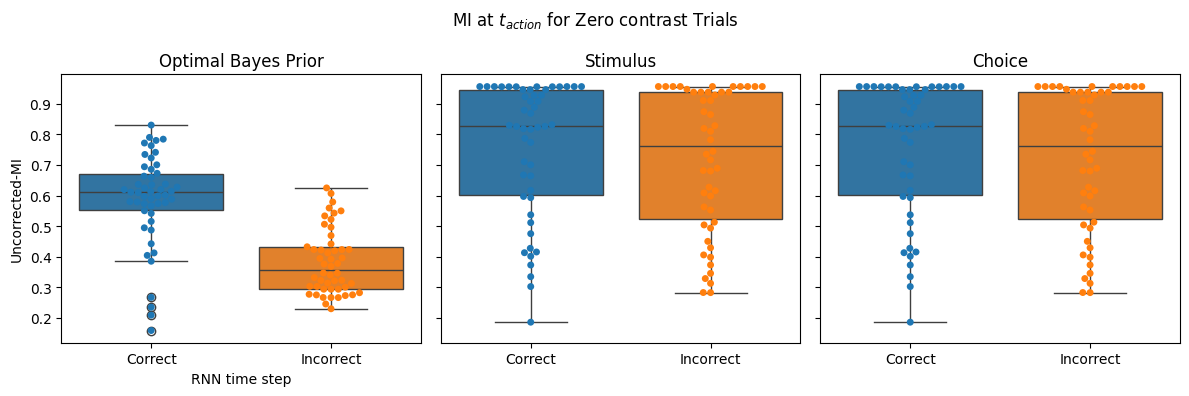

In [302]:
action_scores = np.stack([np.mean(test_scores_action_fold_tzero_contrast_correct, axis=0),np.mean(test_scores_action_fold_tzero_contrast_incorrect, axis=0)], axis=1)
stimulus_scores = np.stack([np.mean(test_scores_trial_fold_tzero_contrast_correct, axis=0),np.mean(test_scores_trial_fold_tzero_contrast_incorrect, axis=0)], axis=1)
bayesian_scores = np.stack([np.mean(test_scores_bayesian_fold_tzero_contrast_correct, axis=0),np.mean(test_scores_bayesian_fold_tzero_contrast_incorrect, axis=0)], axis=1)

fig, ax = plt.subplots(ncols=3, figsize=(12, 4), sharey=True, sharex=True)

sns.boxplot(bayesian_scores,ax=ax[0])
sns.swarmplot(bayesian_scores,ax=ax[0])

sns.boxplot(stimulus_scores,ax=ax[1])
sns.swarmplot(stimulus_scores,ax=ax[1])

sns.boxplot(action_scores,ax=ax[2])
sns.swarmplot(action_scores,ax=ax[2])


ax[0].set_xticks(np.arange(2),labels=['Correct','Incorrect'])
ax[0].set_xlabel('RNN time step')
ax[0].set_ylabel('Uncorrected-MI')
ax[0].set_title('Optimal Bayes Prior')
ax[1].set_title('Stimulus')
ax[2].set_title('Choice')
plt.suptitle('MI at $t_{action}$ for Zero contrast Trials')

plt.tight_layout()

In [248]:
t_zero_contrast.loc[correct_zero_contrast]

,block_side,signed_trial_strength,action_side,trial_side,correct_action_taken,hidden_state,left_stimulus,right_stimulus,rnn_step_index,Bayes
61,1.0,0.0,1.0,1.0,1.0,"[[-0.345296313890662, -0.4554230301906003, -0....",0.438965,1.376953,4.0,1
77,1.0,0.0,1.0,1.0,1.0,"[[-0.4094844185152888, -0.5095179841771305, -0...",1.544922,1.884766,2.0,1
105,-1.0,-0.0,-1.0,-1.0,1.0,"[[0.08224058861145313, -0.6161655029760096, -0...",0.123108,-0.445801,2.0,0
121,-1.0,-0.0,-1.0,-1.0,1.0,"[[0.37366788113034005, -0.49971452538917616, 0...",1.591797,-0.103577,2.0,0
127,-1.0,-0.0,-1.0,-1.0,1.0,"[[0.414926714974038, -0.6553891423127607, 0.10...",-0.466064,-1.562500,2.0,0
...,...,...,...,...,...,...,...,...,...,...
15940,-1.0,-0.0,-1.0,-1.0,1.0,"[[0.48090919725384934, -0.28391745756234404, 0...",0.791504,-1.358398,2.0,0
15943,-1.0,-0.0,-1.0,-1.0,1.0,"[[0.2852323036908265, -0.701937745299424, 0.24...",0.521484,0.039368,2.0,0
16047,1.0,0.0,1.0,1.0,1.0,"[[-0.6021209034031845, -0.549530857258517, -0....",-2.154297,-0.164673,2.0,1
16084,-1.0,-0.0,-1.0,-1.0,1.0,"[[0.2701429994452729, -0.3820328230714, 0.1092...",0.386475,-0.687500,3.0,1


In [249]:
t_zero_contrast.loc[incorrect_zero_contrast]

,block_side,signed_trial_strength,action_side,trial_side,correct_action_taken,hidden_state,left_stimulus,right_stimulus,rnn_step_index,Bayes
74,1.0,0.0,-1.0,1.0,0.0,"[[-0.05988621441397262, 0.27112107853462236, -...",0.789062,-1.257812,3.0,1
133,-1.0,-0.0,1.0,-1.0,0.0,"[[-0.12376761838171163, -0.8494566505374693, 0...",-0.126099,1.989258,2.0,0
136,-1.0,-0.0,1.0,-1.0,0.0,"[[-0.21985496648396932, -0.6852449146342847, 0...",-0.842773,1.069336,2.0,0
157,-1.0,-0.0,1.0,-1.0,0.0,"[[-0.15682409636445274, -0.8554642548233888, 0...",-1.583008,0.580078,2.0,0
184,-1.0,0.0,-1.0,1.0,0.0,"[[0.5835382284849221, -0.6905366610056151, 0.1...",1.314453,-0.653320,2.0,0
...,...,...,...,...,...,...,...,...,...,...
16106,-1.0,-0.0,1.0,-1.0,0.0,"[[-0.3083388792222063, -0.2724663987112166, 0....",-1.166992,-0.426270,3.0,0
16112,-1.0,0.0,-1.0,1.0,0.0,"[[0.11733593566832184, -0.33008487509707046, -...",0.639648,-0.710938,2.0,0
16122,-1.0,-0.0,1.0,-1.0,0.0,"[[-0.32818749380093026, -0.8469684451245544, 0...",-0.991699,1.830078,2.0,0
16178,-1.0,-0.0,1.0,-1.0,0.0,"[[-0.5176915590036654, -0.4364138987755726, 0....",-0.378418,1.346680,6.0,0


In [250]:

print('choice representation')
target = t_1_non_zero['action_side'].values
# _, test_scores_action_fold_t1_non_zero, optimal_bins_t1_non_zero_action = find_optimal_discretization_kfold(hidden_state_t_1_non_zero, target)

print('stimulus representation')
target = t_1_non_zero['trial_side'].values
# _, test_scores_trial_fold_t1_non_zero, optimal_bins_t1_non_zero_trial = find_optimal_discretization_kfold(hidden_state_t_1_non_zero, target)


print('prior representation')
target = t_1_non_zero['Bayes'].values
# _, test_scores_bayesian_fold_t1_non_zero, optimal_bins_t1_non_zero_bayesian = find_optimal_discretization_kfold(hidden_state_t_1_non_zero, target)



choice representation
stimulus representation
prior representation


In [253]:
t_1_non_zero

,block_side,signed_trial_strength,action_side,trial_side,correct_action_taken,hidden_state,left_stimulus,right_stimulus,rnn_step_index,Bayes
2,1.0,0.5,1.0,1.0,NaN,"[[-0.20588453342306082, -0.35912587342131624, ...",-0.415039,-0.132446,2.0,1
26,1.0,-1.5,-1.0,-1.0,NaN,"[[-0.25259256708909356, -0.10714031892562347, ...",2.371094,1.580078,4.0,1
45,1.0,1.0,1.0,1.0,NaN,"[[-0.2492381579189343, -0.4060604770730362, -0...",1.665039,1.250977,5.0,1
49,1.0,-0.5,-1.0,-1.0,NaN,"[[-0.16643524303483967, 0.19938069515929852, -...",0.886230,-0.205078,2.0,1
60,1.0,0.0,1.0,1.0,NaN,"[[-0.2946532665586528, 0.035138016634714456, -...",0.626953,-0.428467,3.0,1
...,...,...,...,...,...,...,...,...,...,...
16125,-1.0,-1.5,-1.0,-1.0,NaN,"[[-0.0027379512945447525, -0.46272149945581414...",0.390381,0.627441,2.0,0
16144,-1.0,1.5,-1.0,1.0,NaN,"[[0.0561744968789859, -0.4591227122667015, 0.2...",2.138672,2.062500,2.0,0
16170,-1.0,2.0,1.0,1.0,NaN,"[[-0.14738368676072483, -0.6425368447673392, 0...",-0.389648,0.991699,3.0,0
16177,-1.0,-0.0,1.0,-1.0,NaN,"[[-0.4288664113740871, -0.20587944837473265, 0...",0.193481,0.445312,5.0,0


In [291]:
discrete = discretize_hidden_state(hidden_state_t_1_non_zero.T,10)

100%|██████████| 50/50 [00:00<00:00, 874.76it/s]


In [292]:
action = t_1_non_zero['action_side'].values
trial = t_1_non_zero['trial_side'].values
prior = t_1_non_zero['Bayes'].values

In [293]:
mi_action = []
for idx in range(50):
    mi_action.append(MI(action, discrete[idx,:]))

mi_trial = []
for idx in range(50):
    mi_trial.append(MI(trial, discrete[idx,:]))

mi_prior = []
for idx in range(50):
    mi_prior.append(MI(prior, discrete[idx,:]))

In [294]:
mi_action = np.asarray(mi_action)
mi_trial = np.asarray(mi_trial)
mi_prior = np.asarray(mi_prior)

In [295]:
stack = np.stack([mi_prior,mi_trial,mi_action], axis=1)

Text(0.5, 1.0, '$T_{action-1}$')

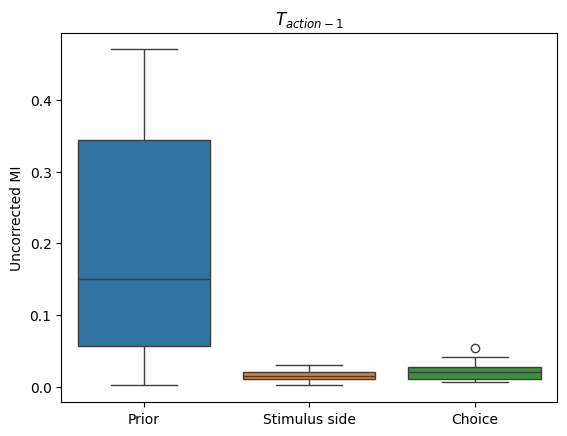

In [296]:
sns.boxplot(stack)
plt.xticks(np.arange(3),['Prior','Stimulus side','Choice'])
plt.ylabel('Uncorrected MI')
plt.title('$T_{action-1}$')

In [317]:
t_zero_contrast.loc[correct_zero_contrast]

,block_side,signed_trial_strength,action_side,trial_side,correct_action_taken,hidden_state,left_stimulus,right_stimulus,rnn_step_index,concordant_trial,Bayes
61,1.0,0.0,1.0,1.0,1.0,"[[-0.345296313890662, -0.4554230301906003, -0....",0.438965,1.376953,4.0,True,1
77,1.0,0.0,1.0,1.0,1.0,"[[-0.4094844185152888, -0.5095179841771305, -0...",1.544922,1.884766,2.0,True,1
105,-1.0,-0.0,-1.0,-1.0,1.0,"[[0.08224058861145313, -0.6161655029760096, -0...",0.123108,-0.445801,2.0,True,0
121,-1.0,-0.0,-1.0,-1.0,1.0,"[[0.37366788113034005, -0.49971452538917616, 0...",1.591797,-0.103577,2.0,True,0
127,-1.0,-0.0,-1.0,-1.0,1.0,"[[0.414926714974038, -0.6553891423127607, 0.10...",-0.466064,-1.562500,2.0,True,0
...,...,...,...,...,...,...,...,...,...,...,...
15940,-1.0,-0.0,-1.0,-1.0,1.0,"[[0.48090919725384934, -0.28391745756234404, 0...",0.791504,-1.358398,2.0,True,0
15943,-1.0,-0.0,-1.0,-1.0,1.0,"[[0.2852323036908265, -0.701937745299424, 0.24...",0.521484,0.039368,2.0,True,0
16047,1.0,0.0,1.0,1.0,1.0,"[[-0.6021209034031845, -0.549530857258517, -0....",-2.154297,-0.164673,2.0,True,1
16084,-1.0,-0.0,-1.0,-1.0,1.0,"[[0.2701429994452729, -0.3820328230714, 0.1092...",0.386475,-0.687500,3.0,True,1


In [319]:
Q = t_zero_contrast.loc[incorrect_zero_contrast]

In [321]:
Q

,block_side,signed_trial_strength,action_side,trial_side,correct_action_taken,hidden_state,left_stimulus,right_stimulus,rnn_step_index,concordant_trial,Bayes
74,1.0,0.0,-1.0,1.0,0.0,"[[-0.05988621441397262, 0.27112107853462236, -...",0.789062,-1.257812,3.0,True,1
133,-1.0,-0.0,1.0,-1.0,0.0,"[[-0.12376761838171163, -0.8494566505374693, 0...",-0.126099,1.989258,2.0,True,0
136,-1.0,-0.0,1.0,-1.0,0.0,"[[-0.21985496648396932, -0.6852449146342847, 0...",-0.842773,1.069336,2.0,True,0
157,-1.0,-0.0,1.0,-1.0,0.0,"[[-0.15682409636445274, -0.8554642548233888, 0...",-1.583008,0.580078,2.0,True,0
184,-1.0,0.0,-1.0,1.0,0.0,"[[0.5835382284849221, -0.6905366610056151, 0.1...",1.314453,-0.653320,2.0,False,0
...,...,...,...,...,...,...,...,...,...,...,...
16106,-1.0,-0.0,1.0,-1.0,0.0,"[[-0.3083388792222063, -0.2724663987112166, 0....",-1.166992,-0.426270,3.0,True,0
16112,-1.0,0.0,-1.0,1.0,0.0,"[[0.11733593566832184, -0.33008487509707046, -...",0.639648,-0.710938,2.0,False,0
16122,-1.0,-0.0,1.0,-1.0,0.0,"[[-0.32818749380093026, -0.8469684451245544, 0...",-0.991699,1.830078,2.0,True,0
16178,-1.0,-0.0,1.0,-1.0,0.0,"[[-0.5176915590036654, -0.4364138987755726, 0....",-0.378418,1.346680,6.0,True,0


In [336]:
df = Q[['block_side','signed_trial_strength','action_side','trial_side','correct_action_taken','left_stimulus','right_stimulus']]

In [339]:
df.head().to_clipboard(index=False)  # Set index=False if you don't want row indices

In [340]:
block_side	signed_trial_strength	action_side	trial_side	correct_action_taken	left_stimulus	right_stimulus
1.0	0.0	-1.0	1.0	0.0	0.789	-1.258
-1.0	-0.0	1.0	-1.0	0.0	-0.1261	1.989
-1.0	-0.0	1.0	-1.0	0.0	-0.843	1.069
-1.0	-0.0	1.0	-1.0	0.0	-1.583	0.58
-1.0	0.0	-1.0	1.0	0.0	1.314	-0.6533


SyntaxError: invalid syntax (1383585836.py, line 1)

In [341]:
df.head()

,block_side,signed_trial_strength,action_side,trial_side,correct_action_taken,left_stimulus,right_stimulus
74,1.0,0.0,-1.0,1.0,0.0,0.789062,-1.257812
133,-1.0,-0.0,1.0,-1.0,0.0,-0.126099,1.989258
136,-1.0,-0.0,1.0,-1.0,0.0,-0.842773,1.069336
157,-1.0,-0.0,1.0,-1.0,0.0,-1.583008,0.580078
184,-1.0,0.0,-1.0,1.0,0.0,1.314453,-0.653320


In [343]:
correct_zero_contrast, incorrect_zero_contrast

(Index([   61,    77,   105,   121,   127,   193,   223,   247,   263,   296,
        ...
        15836, 15888, 15897, 15916, 15934, 15940, 15943, 16047, 16084, 16119],
       dtype='int64', length=524),
 Index([   74,   133,   136,   157,   184,   196,   226,   277,   369,   376,
        ...
        15868, 15879, 15882, 16004, 16044, 16106, 16112, 16122, 16178, 16184],
       dtype='int64', length=301))

In [346]:
correct_zero_contrast.shape[0]/(correct_zero_contrast.shape[0] + incorrect_zero_contrast.shape[0])

0.6351515151515151

In [351]:
t_zero_contrast['b'] = t_zero_contrast['Bayes'].replace(0,-1)

C:\Users\debot\AppData\Local\Temp\ipykernel_4808\3314126645.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  t_zero_contrast['b'] = t_zero_contrast['Bayes'].replace(0,-1)


In [354]:
np.sum(t_zero_contrast['b']==t_zero_contrast['trial_side'])/len(t_zero_contrast['b'])

0.7393939393939394

<Axes: >

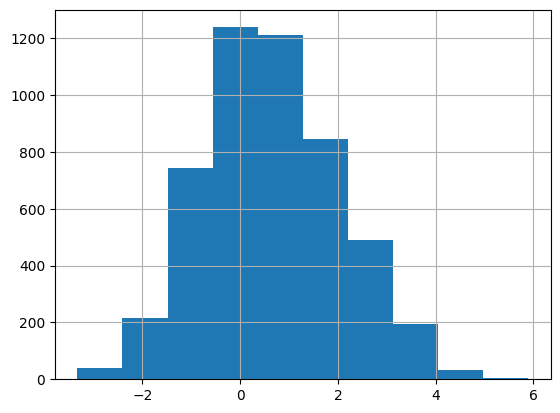

In [357]:
t_end['left_stimulus'].hist()

<Axes: >

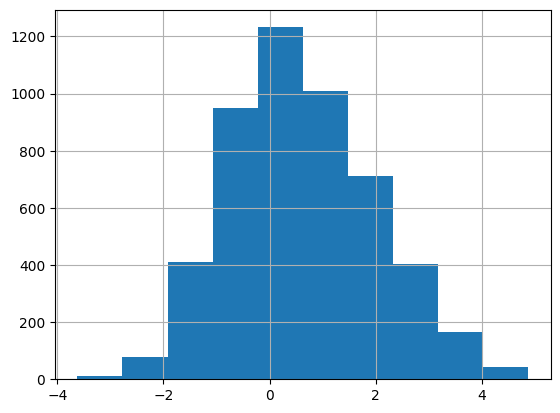

In [358]:
t_end['right_stimulus'].hist()

Text(0, 0.5, 'Right-stimulus')

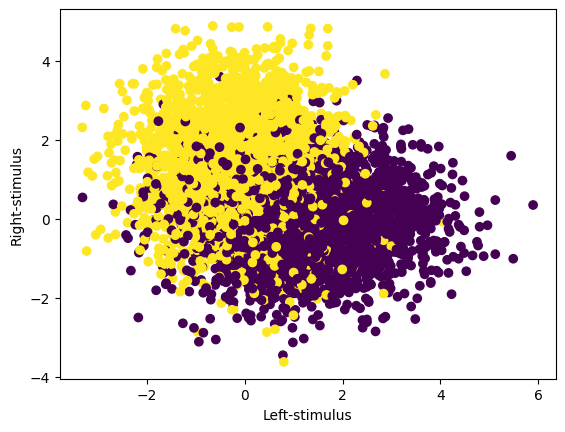

In [376]:
plt.scatter(x=t_end['left_stimulus'], y=t_end['right_stimulus'],c=t_end['trial_side'])
plt.xlabel('Left-stimulus')
plt.ylabel('Right-stimulus')

In [371]:
t_end

,block_side,signed_trial_strength,action_side,trial_side,correct_action_taken,hidden_state,left_stimulus,right_stimulus,rnn_step_index,concordant_trial,Bayes
3,1.0,0.199951,1.0,1.0,1.0,"[[-0.33558813067514154, -0.45776661454258005, ...",-0.640137,0.412354,3.0,True,1
6,1.0,0.600098,1.0,1.0,1.0,"[[-0.2991012494556518, -0.2643218143021266, 0....",0.675781,1.111328,2.0,True,1
9,1.0,0.399902,1.0,1.0,1.0,"[[-0.7252658334326196, -0.5024673096366877, 0....",-1.231445,2.142578,2.0,True,1
12,1.0,0.600098,1.0,1.0,1.0,"[[-0.8431474180724741, -0.27047470563437104, 0...",-1.903320,2.478516,2.0,True,1
15,1.0,0.600098,1.0,1.0,1.0,"[[-0.8319826679786207, -0.07369130127681635, 0...",-1.213867,2.484375,2.0,True,1
...,...,...,...,...,...,...,...,...,...,...,...
16181,-1.0,-0.600098,1.0,-1.0,0.0,"[[-0.6170365753399453, -0.23021537547549117, 0...",-1.142578,0.987793,2.0,True,0
16184,-1.0,-0.000000,1.0,-1.0,0.0,"[[-0.38493803309318836, 0.14676609922924708, -...",-0.231201,-0.144897,2.0,True,0
16187,-1.0,-0.600098,1.0,-1.0,0.0,"[[-0.5483682165234434, -0.08617737393520994, -...",-0.606934,0.409424,2.0,True,0
16190,-1.0,1.000000,1.0,1.0,1.0,"[[-0.6309903018180847, -0.07859663899124439, -...",-0.791992,0.838379,2.0,False,0
